# CSCI 567 — Pre-final: Temporally Robust and Fair Credit Risk Prediction
**LendingClub 2007–2018**

- Exp 1: Temporal Robustness — temporal vs random split AUC drop
- Exp 2: Model Design Effects — hyperparameter sweep
- Exp 3: Fairness Analysis — credit history group + income group
- Exp 4: Robustness–Fairness Trade-off
- Exp 5: Neural Network
- Annual AUC trend (2015, 2016, 2017, 2018)

## 0. Setup Environment & Data Load

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/Colab Notebooks/CSCI567/lendingclub/archive.zip" /content/
!unzip -q /content/archive.zip -d /content/

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/accepted_2007_to_2018Q4.csv.gz', low_memory=False)
# df = pd.read_csv(
#     '/content/drive/MyDrive/Colab Notebooks/CSCI567/accepted_2007_to_2018Q4.csv',
#     low_memory=False
# )

print(f'Raw shape: {df.shape}')

Raw shape: (2260701, 151)


In [4]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.6 MB/s eta 0:00:00


## 1. Preprocessing

In [5]:
# ── Target Creation
default_labels = ['Charged Off', 'Default',
                  'Does not meet the credit policy. Status:Charged Off']
df['target'] = df['loan_status'].isin(default_labels).astype(int)

# ── Current 등 미확정 제거
confirmed_status = ['Fully Paid', 'Charged Off', 'Default',
                    'Does not meet the credit policy. Status:Charged Off',
                    'Does not meet the credit policy. Status:Fully Paid']
df = df[df['loan_status'].isin(confirmed_status)]
print(f'After removing unconfirmed: {df.shape}')

# ── Date Parsing
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year
df['age_proxy'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['credit_history_years'] = (df['issue_d'] - df['age_proxy']).dt.days / 365

# ── Feature Selection
FEATURES = ['loan_amnt', 'int_rate', 'installment', 'annual_inc',
            'dti', 'delinq_2yrs', 'fico_range_low', 'open_acc',
            'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
            'mort_acc', 'pub_rec_bankruptcies']

# ── Sampling (Colab)
df_sample = df.sample(n=200000, random_state=42).copy()
print(f'Sample shape: {df_sample.shape}')
print(f'Default rate: {df_sample["target"].mean():.3f}')

After removing unconfirmed: (1348099, 152)
Sample shape: (200000, 155)
Default rate: 0.200


In [6]:
print(df_sample.columns.tolist())
print(df_sample['loan_status'].unique())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

In [7]:
# Fairness groups will be created after splitting so the cutoffs are learned
# from the temporal training data only.
print('Fairness groups will be built after the split step.')

Fairness groups will be built after the split step.


## 2. Data Splitting

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Temporal split: train / val / test ───────────────────────────────────────
train_t = df_sample[df_sample['issue_year'] <= 2013].copy()
val_t   = df_sample[(df_sample['issue_year'] >= 2014) & (df_sample['issue_year'] <= 2015)].copy()
test_t  = df_sample[df_sample['issue_year'] >= 2016].copy()

# ── Random split: train / val / test ─────────────────────────────────────────
rand_train_df, rand_temp_df = train_test_split(
    df_sample, test_size=0.30, random_state=42, stratify=df_sample['target'])

rand_val_df, rand_test_df = train_test_split(
    rand_temp_df, test_size=0.50, random_state=42, stratify=rand_temp_df['target'])

# ── Imputation: learn medians from training splits only ──────────────────────
temporal_fill = train_t[FEATURES + ['credit_history_years']].median()
random_fill   = rand_train_df[FEATURES + ['credit_history_years']].median()

for split_df in [train_t, val_t, test_t]:
    split_df[FEATURES + ['credit_history_years']] = split_df[FEATURES + ['credit_history_years']].fillna(temporal_fill)

for split_df in [rand_train_df, rand_val_df, rand_test_df]:
    split_df[FEATURES + ['credit_history_years']] = split_df[FEATURES + ['credit_history_years']].fillna(random_fill)

# ── Fairness groups: learn cutoffs from temporal train only ──────────────────
credit_bins = pd.qcut(train_t['credit_history_years'], q=3, retbins=True, duplicates='drop')[1]
income_clip_top = train_t['annual_inc'].quantile(0.99)
income_bins = pd.qcut(train_t['annual_inc'].clip(upper=income_clip_top), q=3, retbins=True, duplicates='drop')[1]

credit_bins[0] = -np.inf
credit_bins[-1] = np.inf
income_bins[0] = -np.inf
income_bins[-1] = np.inf

for split_df in [train_t, val_t, test_t, rand_train_df, rand_val_df, rand_test_df]:
    split_df['credit_group'] = pd.cut(split_df['credit_history_years'], bins=credit_bins, labels=['short', 'mid', 'long'], include_lowest=True)
    split_df['income_group'] = pd.cut(split_df['annual_inc'].clip(upper=income_clip_top), bins=income_bins, labels=['low', 'mid', 'high'], include_lowest=True)

X_train_t = train_t[FEATURES]
y_train_t = train_t['target']
X_val_t   = val_t[FEATURES]
y_val_t   = val_t['target']
X_test_t  = test_t[FEATURES]
y_test_t  = test_t['target']

X_rand_tr  = rand_train_df[FEATURES]
y_rand_tr  = rand_train_df['target']
X_rand_val = rand_val_df[FEATURES]
y_rand_val = rand_val_df['target']
X_rand_te  = rand_test_df[FEATURES]
y_rand_te  = rand_test_df['target']

# ── Scaling: fit each scaler on its own training split only ──────────────────
scaler_t = StandardScaler()
X_train_t_sc = scaler_t.fit_transform(X_train_t)
X_val_t_sc   = scaler_t.transform(X_val_t)
X_test_t_sc  = scaler_t.transform(X_test_t)

scaler_r = StandardScaler()
X_rand_tr_sc  = scaler_r.fit_transform(X_rand_tr)
X_rand_val_sc = scaler_r.transform(X_rand_val)
X_rand_te_sc  = scaler_r.transform(X_rand_te)

print('Temporal split')
print(f'  Train (<=2013):   {len(X_train_t):,}')
print(f'  Val (2014-2015):  {len(X_val_t):,}')
print(f'  Test (>=2016):    {len(X_test_t):,}')

print('\nRandom split')
print(f'  Train: {len(X_rand_tr):,}')
print(f'  Val:   {len(X_rand_val):,}')
print(f'  Test:  {len(X_rand_te):,}')

print('\nTemporal-train fairness group distribution')
print(train_t['credit_group'].value_counts())
print(train_t['income_group'].value_counts())

print('\nYearly default count')
for yr in sorted(df_sample['issue_year'].unique()):
    sub = df_sample[df_sample['issue_year'] == yr]
    print(f'  {yr}: total={len(sub):,}  default={sub["target"].sum():,}  default_rate={sub["target"].mean():.3f}')

Temporal split
  Train (<=2013):   34,358
  Val (2014-2015):  88,462
  Test (>=2016):    77,180

Random split
  Train: 140,000
  Val:   30,000
  Test:  30,000

Temporal-train fairness group distribution
credit_group
short    11483
mid      11440
long     11435
Name: count, dtype: int64
income_group
low     12073
high    11369
mid     10916
Name: count, dtype: int64

Yearly default count
  2007: total=103  default=22  default_rate=0.214
  2008: total=360  default=78  default_rate=0.217
  2009: total=807  default=123  default_rate=0.152
  2010: total=1,887  default=267  default_rate=0.141
  2011: total=3,188  default=471  default_rate=0.148
  2012: total=8,048  default=1,243  default_rate=0.154
  2013: total=19,965  default=3,179  default_rate=0.159
  2014: total=33,258  default=6,223  default_rate=0.187
  2015: total=55,204  default=11,047  default_rate=0.200
  2016: total=43,650  default=10,219  default_rate=0.234
  2017: total=25,107  default=5,887  default_rate=0.234
  2018: total=8,

In [9]:
# ── By year temporal test sets (AUC over time) ──────────────────────────────
yearly_tests = {}
for yr in [2016, 2017, 2018]:
    sub = df_sample[df_sample['issue_year'] == yr].copy()
    if len(sub) > 0:
        sub[FEATURES + ['credit_history_years']] = sub[FEATURES + ['credit_history_years']].fillna(temporal_fill)
        sub['credit_group'] = pd.cut(sub['credit_history_years'], bins=credit_bins, labels=['short', 'mid', 'long'], include_lowest=True)
        sub['income_group'] = pd.cut(sub['annual_inc'].clip(upper=income_clip_top), bins=income_bins, labels=['low', 'mid', 'high'], include_lowest=True)
        yearly_tests[yr] = (sub[FEATURES], sub['target'], scaler_t.transform(sub[FEATURES]), sub)
        print(f'{yr}: {len(sub):,} samples, default rate={sub["target"].mean():.3f}')

2016: 43,650 samples, default rate=0.234
2017: 25,107 samples, default rate=0.234
2018: 8,423 samples, default rate=0.158


## 3. Model Definition — Full Model + Hyperparameter Sweep


In [10]:
# Reusable evaluation helpers for any model family
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss
from sklearn.metrics import recall_score, f1_score, precision_score
import time

def evaluate_model_configs(model_configs):
    eval_results = {}
    for name, (model, input_type) in model_configs.items():
        t0 = time.time()
        temporal_model = clone(model)
        random_model   = clone(model)

        if input_type == 'scaled':
            Xtr_t, Xva_t, Xte_t = X_train_t_sc, X_val_t_sc, X_test_t_sc
            Xtr_r, Xva_r, Xte_r = X_rand_tr_sc, X_rand_val_sc, X_rand_te_sc
        else:
            Xtr_t, Xva_t, Xte_t = X_train_t, X_val_t, X_test_t
            Xtr_r, Xva_r, Xte_r = X_rand_tr, X_rand_val, X_rand_te

        temporal_model.fit(Xtr_t, y_train_t)
        random_model.fit(Xtr_r, y_rand_tr)

        y_prob_t_val = temporal_model.predict_proba(Xva_t)[:, 1]
        y_prob_t = temporal_model.predict_proba(Xte_t)[:, 1]
        # y_pred_t_val = temporal_model.predict(Xva_t)
        # y_pred_t = temporal_model.predict(Xte_t)

        y_prob_r_val = random_model.predict_proba(Xva_r)[:, 1]
        y_prob_r = random_model.predict_proba(Xte_r)[:, 1]
        # y_pred_r_val = random_model.predict(Xva_r)
        # y_pred_r = random_model.predict(Xte_r)

        # val set optimal threshold
        thresholds = np.arange(0.05, 0.50, 0.01)
        best_thr_t = max(thresholds, key=lambda t: f1_score(y_val_t, (y_prob_t_val >= t).astype(int), zero_division=0))
        best_thr_r = max(thresholds, key=lambda t: f1_score(y_rand_val, (y_prob_r_val >= t).astype(int), zero_division=0))

        # apply threshold
        y_pred_t_val = (y_prob_t_val >= best_thr_t).astype(int)
        y_pred_t = (y_prob_t >= best_thr_t).astype(int)
        y_pred_r_val = (y_prob_r_val >= best_thr_r).astype(int)
        y_pred_r = (y_prob_r >= best_thr_r).astype(int)

        eval_results[name] = {
            'temporal': {
                'val_y_prob': y_prob_t_val,
                'val_y_pred': y_pred_t_val,
                'val_auc': roc_auc_score(y_val_t, y_prob_t_val),
                'val_acc': accuracy_score(y_val_t, y_pred_t_val),
                'val_brier': brier_score_loss(y_val_t, y_prob_t_val),
                'val_recall': recall_score(y_val_t, y_pred_t_val, zero_division=0),
                'val_precision': precision_score(y_val_t, y_pred_t_val, zero_division=0),
                'val_f1': f1_score(y_val_t, y_pred_t_val, zero_division=0),
                'y_pred': y_pred_t,
                'y_prob': y_prob_t,
                'auc': roc_auc_score(y_test_t, y_prob_t),
                'acc': accuracy_score(y_test_t, y_pred_t),
                'brier': brier_score_loss(y_test_t, y_prob_t),
                'recall': recall_score(y_test_t, y_pred_t, zero_division=0),
                'precision': precision_score(y_test_t, y_pred_t, zero_division=0),
                'f1': f1_score(y_test_t, y_pred_t, zero_division=0),
                'threshold': best_thr_t,
                'model': temporal_model,
            },
            'random': {
                'val_y_prob': y_prob_r_val,
                'val_y_pred': y_pred_r_val,
                'val_auc': roc_auc_score(y_rand_val, y_prob_r_val),
                'val_acc': accuracy_score(y_rand_val, y_pred_r_val),
                'val_brier': brier_score_loss(y_rand_val, y_prob_r_val),
                'val_recall': recall_score(y_rand_val, y_pred_r_val, zero_division=0),
                'val_precision': precision_score(y_rand_val, y_pred_r_val, zero_division=0),
                'val_f1': f1_score(y_rand_val, y_pred_r_val, zero_division=0),
                'y_prob': y_prob_r,
                'y_pred': y_pred_r,
                'auc': roc_auc_score(y_rand_te, y_prob_r),
                'acc': accuracy_score(y_rand_te, y_pred_r),
                'brier': brier_score_loss(y_rand_te, y_prob_r),
                'recall': recall_score(y_rand_te, y_pred_r, zero_division=0),
                'precision': precision_score(y_rand_te, y_pred_r, zero_division=0),
                'f1': f1_score(y_rand_te, y_pred_r, zero_division=0),
                'threshold': best_thr_r,
                'model': random_model,
            },
            'yearly': {}
        }

        for yr, (X_yr, y_yr, X_yr_sc, _) in yearly_tests.items():
            X_in = X_yr_sc if input_type == 'scaled' else X_yr
            yp = temporal_model.predict_proba(X_in)[:, 1]
            eval_results[name]['yearly'][yr] = roc_auc_score(y_yr, yp)

        eval_results[name]['auc_drop'] = eval_results[name]['random']['auc'] - eval_results[name]['temporal']['auc']
        eval_results[name]['val_auc_drop'] = eval_results[name]['random']['val_auc'] - eval_results[name]['temporal']['val_auc']
    return eval_results


In [11]:
def print_selection_table(eval_results, sort_key='val_auc', reverse=True, title=None, mode='val'):
    if title:
        print(f'\n=== {title} ===')

    if mode == 'val':
        key_fn = {
            'val_auc': lambda x: x[1]['temporal']['val_auc'],
            'val_auc_drop': lambda x: x[1]['val_auc_drop'],
            'val_recall': lambda x: x[1]['temporal']['val_recall'],
            'val_precision': lambda x: x[1]['temporal']['val_precision'],
            'val_f1': lambda x: x[1]['temporal']['val_f1'],
        }.get(sort_key, lambda x: x[1]['temporal']['val_auc'])

        for name, res in sorted(eval_results.items(), key=key_fn, reverse=reverse):
            print(f"{name:20s}  "
                  f"temp_val_AUC={res['temporal']['val_auc']:.4f}  "
                  f"rand_val_AUC={res['random']['val_auc']:.4f}  "
                  f"val_AUC_drop={res['val_auc_drop']:.4f}  "
                  f"val_Recall={res['temporal']['val_recall']:.4f}  "
                  f"val_Precision={res['temporal']['val_precision']:.4f}  "
                  f"val_F1={res['temporal']['val_f1']:.4f}  "
                  f"threshold={res['temporal']['threshold']:.2f}")

    elif mode == 'test':
        key_fn = {
            'test_auc': lambda x: x[1]['temporal']['auc'],
            'test_auc_drop': lambda x: x[1]['auc_drop'],
            'recall': lambda x: x[1]['temporal']['recall'],
            'precision': lambda x: x[1]['temporal']['precision'],
            'f1': lambda x: x[1]['temporal']['f1'],
        }.get(sort_key, lambda x: x[1]['temporal']['auc'])

        for name, res in sorted(eval_results.items(), key=key_fn, reverse=reverse):
            print(f"{name:20s}  "
                  f"temp_test_AUC={res['temporal']['auc']:.4f}  "
                  f"random_test_AUC={res['random']['auc']:.4f}  "
                  f"test_AUC_drop={res['auc_drop']:.4f}  "
                  f"Recall={res['temporal']['recall']:.4f}  "
                  f"Precision={res['temporal']['precision']:.4f}  "
                  f"F1={res['temporal']['f1']:.4f}  "
                  f"threshold={res['temporal']['threshold']:.2f}")

In [12]:
def print_best_summary(eval_results, prefix=None, title=None):
    # prefix filtering (ex: 'XGB_', 'LR_', 'RF_')
    filtered = {k: v for k, v in eval_results.items()
                if (k.startswith(prefix) if prefix else True)}

    best_val      = max(filtered.items(), key=lambda x: x[1]['temporal']['val_auc'])
    best_robust   = min(filtered.items(), key=lambda x: x[1]['auc_drop'])
    best_balanced = max(filtered.items(), key=lambda x: x[1]['temporal']['val_auc'] - x[1]['auc_drop'])

    if title:
        print(f'=== {title} ===')

    print(f"Best by temporal val AUC: {best_val[0]}")
    print(f"  val_AUC={best_val[1]['temporal']['val_auc']:.4f}  test_AUC={best_val[1]['temporal']['auc']:.4f}  AUC_drop={best_val[1]['auc_drop']:.4f}")
    print()
    print(f"Best by robustness (smallest AUC drop): {best_robust[0]}")
    print(f"  val_AUC={best_robust[1]['temporal']['val_auc']:.4f}  test_AUC={best_robust[1]['temporal']['auc']:.4f}  AUC_drop={best_robust[1]['auc_drop']:.4f}")
    print()
    print(f"Best balanced (val_AUC - AUC_drop): {best_balanced[0]}")
    print(f"  val_AUC={best_balanced[1]['temporal']['val_auc']:.4f}  test_AUC={best_balanced[1]['temporal']['auc']:.4f}  AUC_drop={best_balanced[1]['auc_drop']:.4f}")

In [13]:
def print_optuna_results(study, top_trials, title='Optuna Results'):
    print(f'\n=== {title} ===')
    print(f'Best score: {study.best_value:.4f}')
    print(f'\nBest params:')
    for k, v in study.best_params.items():
        print(f'  {k:20s}: {v}')

    print(f'\n=== Top {len(top_trials)} Trials ===')
    for i, t in enumerate(top_trials):
        print(f'\n[{i+1}] score={t.value:.4f}')
        for k, v in t.params.items():
            print(f'  {k:20s}: {v}')

In [14]:
import optuna
from optuna.samplers import TPESampler

w_robustness = 0.35
w_performance = 0.15
w_recall = 0.50
w_f1 = 0.50

## 3.1 XGBoost Test Code (Find Best)


## 3.1.1 XGBoost Grid Search


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# ── All Model Definitions ─────────────────────────────────────────────────────
# LR: C Value sweep (regularization strength)
# Tree: max_depth sweep
# RF: n_estimators x max_depth
# XGB: learning_rate x max_depth
# NN: hidden layer size x alpha (L2)

XGB_MODEL_CONFIGS = {
    # Baseline
    'XGB_base':         (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),

    # learning_rate sweep
    'XGB_lr0.005':       (XGBClassifier(n_estimators=100, learning_rate=0.005, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_lr0.3':        (XGBClassifier(n_estimators=100, learning_rate=0.3,  max_depth=4, eval_metric='logloss', random_state=42), 'raw'),

    # max_depth sweep
    'XGB_d3_lr0.01':           (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d6_lr0.01':           (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d8_lr0.01':           (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d3_lr0.03':           (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d6_lr0.03':           (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d8_lr0.03':           (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d3_lr0.05':           (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d6_lr0.05':           (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d8_lr0.05':           (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=8, eval_metric='logloss', random_state=42), 'raw'),

    # min_child_weight sweep
    'XGB_mcw3_lr0.01':         (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3,  eval_metric='logloss', random_state=42), 'raw'),
    'XGB_mcw5_lr0.01':         (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=5,  eval_metric='logloss', random_state=42), 'raw'),
    'XGB_mcw10_lr0.01':        (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=10, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_mcw3_lr0.03':         (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3,  eval_metric='logloss', random_state=42), 'raw'),
    'XGB_mcw5_lr0.03':         (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=5,  eval_metric='logloss', random_state=42), 'raw'),
    'XGB_mcw10_lr0.03':        (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=10, eval_metric='logloss', random_state=42), 'raw'),

    # subsample sweep
    'XGB_sub0.6_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, subsample=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.7_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.8_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, subsample=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.6_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, subsample=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.7_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.8_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, subsample=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.6_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, subsample=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.7_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.8_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, subsample=0.8, eval_metric='logloss', random_state=42), 'raw'),

    # colsample_bytree sweep
    'XGB_col0.6_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.6_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.6_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),

    # colsample_bytree sweep
    'XGB_col0.6_lr0.01_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.01_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.01_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.6_lr0.03_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.03_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.03_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.6_lr0.05_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.05_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.05_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),

    # colsample_bytree sweep
    'XGB_col0.6_lr0.01_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, subsample=0.7, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.01_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, subsample=0.7, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.01_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, subsample=0.7, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.6_lr0.03_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, subsample=0.7, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.03_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, subsample=0.7, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.03_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, subsample=0.7, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.6_lr0.05_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.7, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.05_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.7, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.05_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.7, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),

    # subsample sweep
    'XGB_gamma1_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma3_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma5_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma1_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma3_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma5_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma1_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma3_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma5_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),

    # L1 (reg_alpha) + gamma + lr 조합
    'XGB_L1_1_g1_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g1_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g1_lr0.01': (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_1_g3_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g3_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g3_lr0.01': (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_1_g5_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g5_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g5_lr0.01': (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),

    'XGB_L1_1_g1_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g1_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g1_lr0.03': (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_1_g3_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g3_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g3_lr0.03': (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_1_g5_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g5_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g5_lr0.03': (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),

    'XGB_L1_1_g1_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g1_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g1_lr0.05': (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_1_g3_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g3_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g3_lr0.05': (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_1_g5_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g5_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g5_lr0.05': (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),

    # L2 (reg_lambda) + gamma + lr (27)
    # 'XGB_L2_1_g1_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g1_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g1_lr0.01': (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_1_g3_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g3_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g3_lr0.01': (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_1_g5_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g5_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g5_lr0.01': (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),

    # 'XGB_L2_1_g1_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g1_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g1_lr0.03': (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_1_g3_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g3_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g3_lr0.03': (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_1_g5_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g5_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g5_lr0.03': (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),

    # 'XGB_L2_1_g1_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g1_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g1_lr0.05': (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_1_g3_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g3_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g3_lr0.05': (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_1_g5_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g5_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g5_lr0.05': (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),

    'XGB_L2(1)_g1_lr0.01_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.01_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.01_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.03_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.03_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.03_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.05_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.05_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.05_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.01_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.01_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.01_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.03_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.03_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.03_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.05_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.05_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.05_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.01_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.01_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.01_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.03_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.03_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.03_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.05_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.05_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.05_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
}

print(f'Total model configs: {len(XGB_MODEL_CONFIGS)}')

Total model configs: 119


In [16]:
# xgb_results = evaluate_model_configs(XGB_MODEL_CONFIGS)

# # (val set)
# print_selection_table(xgb_results, sort_key='val_auc', reverse=True, title='XGB - Val Set', mode='val')
# print_selection_table(xgb_results, sort_key='val_auc_drop', reverse=False, title='XGB - Val Robustness', mode='val')

# # (test set)
# print_selection_table(xgb_results, sort_key='test_auc', reverse=True, title='XGB - Test Set (Final)', mode='test')
# print_selection_table(xgb_results, sort_key='test_auc_drop', reverse=False, title='XGB - Test Robustness (Final)', mode='test')

# # (best summary)
# print_best_summary(xgb_results, prefix='XGB_', title='XGBoost Selection Summary')

## 3.1.2 XGBoost Bayesian Search

In [17]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 4),
        'subsample': trial.suggest_float('subsample', 0.6, 0.85),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 3.0),
        'scale_pos_weight': trial.suggest_categorical('scale_pos_weight', [1, 5, 8]),
    }

    model = XGBClassifier(**params, eval_metric='logloss', random_state=42)
    model.fit(X_train_t, y_train_t)
    model_r = XGBClassifier(**params, eval_metric='logloss', random_state=42)
    model_r.fit(X_rand_tr, y_rand_tr)

    val_auc = roc_auc_score(y_val_t, model.predict_proba(X_val_t)[:, 1])
    rand_auc = roc_auc_score(y_rand_val, model_r.predict_proba(X_rand_val)[:, 1])
    auc_drop = rand_auc - val_auc

    y_prob_val = model.predict_proba(X_val_t)[:, 1]
    thresholds = np.arange(0.05, 0.50, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t, (y_prob_val >= t).astype(int), zero_division=0))
    val_f1 = f1_score(y_val_t, (y_prob_val >= best_thr).astype(int), zero_division=0)

    return w_performance * val_auc - w_robustness * auc_drop + w_f1 * val_f1

study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=60, show_progress_bar=True)

[I 2026-05-07 05:05:47,891] A new study created in memory with name: no-name-bae26ab9-4c4d-4313-8e62-3ad411e34de4


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-05-07 05:05:51,679] Trial 0 finished with value: 0.3114826590447485 and parameters: {'n_estimators': 87, 'learning_rate': 0.046187109390049115, 'max_depth': 4, 'subsample': 0.7496646210492591, 'gamma': 0.7800932022121826, 'reg_lambda': 1.3119890406724053, 'scale_pos_weight': 5}. Best is trial 0 with value: 0.3114826590447485.
[I 2026-05-07 05:05:54,123] Trial 1 finished with value: 0.2993299857773662 and parameters: {'n_estimators': 121, 'learning_rate': 0.010336843570697411, 'max_depth': 4, 'subsample': 0.8081106602001054, 'gamma': 1.0616955533913808, 'reg_lambda': 1.3636499344142012, 'scale_pos_weight': 8}. Best is trial 0 with value: 0.3114826590447485.
[I 2026-05-07 05:05:56,213] Trial 2 finished with value: 0.3104816947115907 and parameters: {'n_estimators': 93, 'learning_rate': 0.01597939871741036, 'max_depth': 4, 'subsample': 0.6348734651630105, 'gamma': 1.4607232426760908, 'reg_lambda': 1.7327236865873834, 'scale_pos_weight': 5}. Best is trial 0 with value: 0.3114826590

In [18]:
# ── best 10 => XGB_MODEL_CONFIGS ──────────────────────────────
trials_df = study_xgb.trials_dataframe().sort_values('value', ascending=False).head(10)

XGB_MODEL_CONFIGS = {}
for i, row in enumerate(study_xgb.trials):
    if i >= 10:
        break
top_trials = sorted(study_xgb.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:10]

for i, t in enumerate(top_trials):
    name = f'XGB_optuna_{i+1}'
    XGB_MODEL_CONFIGS[name] = (
        XGBClassifier(**t.params, eval_metric='logloss', random_state=42), 'raw'
    )

# ── evaluation ────────────────────────────────────────────────
xgb_results = evaluate_model_configs(XGB_MODEL_CONFIGS)

# (val set)
print_selection_table(xgb_results, sort_key='val_auc', reverse=True, title='XGB - Val Set', mode='val')
print_selection_table(xgb_results, sort_key='val_auc_drop', reverse=False, title='XGB - Val Robustness', mode='val')
print_selection_table(xgb_results, sort_key='val_recall', reverse=True, title='XGB - Val Recall', mode='val')

# (test set)
print_selection_table(xgb_results, sort_key='test_auc', reverse=True, title='XGB - Test Set (Final)', mode='test')
print_selection_table(xgb_results, sort_key='test_auc_drop', reverse=False, title='XGB - Test Robustness (Final)', mode='test')
print_selection_table(xgb_results, sort_key='recall', reverse=True, title='XGB - Test Recall (Final)', mode='test')

# (best summary)
print_best_summary(xgb_results, prefix='XGB_', title='XGBoost Selection Summary')

# ── Hyperparameter print ──────────────────────────────────────
print_optuna_results(study_xgb, top_trials, title='XGB Optuna Hyperparameter Results')


=== XGB - Val Set ===
XGB_optuna_1          temp_val_AUC=0.7035  rand_val_AUC=0.7054  val_AUC_drop=0.0019  val_Recall=0.6164  val_Precision=0.3157  val_F1=0.4176  threshold=0.46
XGB_optuna_6          temp_val_AUC=0.7033  rand_val_AUC=0.7058  val_AUC_drop=0.0025  val_Recall=0.6494  val_Precision=0.3069  val_F1=0.4168  threshold=0.14
XGB_optuna_10         temp_val_AUC=0.7032  rand_val_AUC=0.7065  val_AUC_drop=0.0033  val_Recall=0.6098  val_Precision=0.3170  val_F1=0.4172  threshold=0.46
XGB_optuna_2          temp_val_AUC=0.7031  rand_val_AUC=0.7057  val_AUC_drop=0.0025  val_Recall=0.6583  val_Precision=0.3061  val_F1=0.4179  threshold=0.44
XGB_optuna_4          temp_val_AUC=0.7030  rand_val_AUC=0.7058  val_AUC_drop=0.0029  val_Recall=0.6109  val_Precision=0.3170  val_F1=0.4174  threshold=0.46
XGB_optuna_5          temp_val_AUC=0.7029  rand_val_AUC=0.7056  val_AUC_drop=0.0026  val_Recall=0.5909  val_Precision=0.3222  val_F1=0.4171  threshold=0.47
XGB_optuna_3          temp_val_AUC=0.7029

## 3.2 Logistic Regression Test Code (Find Best)


## 3.2.1 LR Gird Search

In [19]:
LR_MODEL_CONFIGS = {
    # 1) L2 sweep
    'LR_L2_C0.0001': (LogisticRegression(C=0.0001, penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L2_C0.001':  (LogisticRegression(C=0.001,  penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L2_C0.01':   (LogisticRegression(C=0.01,   penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L2_C0.1':    (LogisticRegression(C=0.1,    penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L2_C1':      (LogisticRegression(C=1.0,    penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L2_C10':     (LogisticRegression(C=10.0,   penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L2_C100':    (LogisticRegression(C=100.0,  penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),

    # 2) L1 sweep (sparsity)
    'LR_L1_C0.001':  (LogisticRegression(C=0.0001,  penalty='l1', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L1_C0.01':   (LogisticRegression(C=0.001,   penalty='l1', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L1_C0.1':    (LogisticRegression(C=0.01,    penalty='l1', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L1_C1':      (LogisticRegression(C=1.0,    penalty='l1', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L1_C10':     (LogisticRegression(C=10.0,   penalty='l1', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L1_C100':    (LogisticRegression(C=100.0,  penalty='l1', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),

    # 3) ElasticNet sweep (L1+L2)
    'LR_EN_C0.0001_l10.3':  (LogisticRegression(C=0.0001,  penalty='elasticnet', solver='saga', l1_ratio=0.3, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.0001_l10.5':  (LogisticRegression(C=0.0001,  penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.0001_l10.7':  (LogisticRegression(C=0.0001,  penalty='elasticnet', solver='saga', l1_ratio=0.7, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.001_l10.05':   (LogisticRegression(C=0.001,   penalty='elasticnet', solver='saga', l1_ratio=0.05, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.001_l10.1':   (LogisticRegression(C=0.001,   penalty='elasticnet', solver='saga', l1_ratio=0.1, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.001_l10.2':   (LogisticRegression(C=0.001,   penalty='elasticnet', solver='saga', l1_ratio=0.2, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.001_l10.3':   (LogisticRegression(C=0.001,   penalty='elasticnet', solver='saga', l1_ratio=0.3, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.001_l10.5':   (LogisticRegression(C=0.001,   penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.001_l10.7':   (LogisticRegression(C=0.001,   penalty='elasticnet', solver='saga', l1_ratio=0.7, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.01_l10.3':     (LogisticRegression(C=1.01,   penalty='elasticnet', solver='saga', l1_ratio=0.3, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.01_l10.5':     (LogisticRegression(C=1.01,   penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.01_l10.7':     (LogisticRegression(C=1.01,   penalty='elasticnet', solver='saga', l1_ratio=0.7, max_iter=2000, random_state=42), 'scaled'),
}

print(f'Total LR model configs: {len(LR_MODEL_CONFIGS)}')

Total LR model configs: 25


In [20]:
# lr_results = evaluate_model_configs(LR_MODEL_CONFIGS)

# # (val set)
# print_selection_table(lr_results, sort_key='val_auc', reverse=True, title='LR - Val Set', mode='val')
# print_selection_table(lr_results, sort_key='val_auc_drop', reverse=False, title='LR - Val Robustness', mode='val')

# # (test set)
# print_selection_table(lr_results, sort_key='test_auc', reverse=True, title='LR - Test Set (Final)', mode='test')
# print_selection_table(lr_results, sort_key='test_auc_drop', reverse=False, title='LR - Test Robustness (Final)', mode='test')

# # (best summary)
# print_best_summary(lr_results, prefix='LR_', title='Logistic Regression Selection Summary')

## 3.2.2 LR Bayesian Search

In [21]:
def objective_lr(trial):
    penalty = trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet'])
    C = trial.suggest_float('C', 1e-4, 1e-2, log=True)

    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0.05, 0.3)
        solver = 'saga'
    elif penalty == 'l1':
        l1_ratio = None
        solver = 'liblinear'
    else:
        l1_ratio = None
        solver = 'liblinear'

    kwargs = dict(C=C, penalty=penalty, solver=solver, class_weight='balanced', max_iter=2000, random_state=42)
    if l1_ratio is not None:
        kwargs['l1_ratio'] = l1_ratio

    model = LogisticRegression(**kwargs)
    model.fit(X_train_t_sc, y_train_t)
    model_r = LogisticRegression(**kwargs)
    model_r.fit(X_rand_tr_sc, y_rand_tr)

    val_auc = roc_auc_score(y_val_t, model.predict_proba(X_val_t_sc)[:, 1])
    rand_auc = roc_auc_score(y_rand_val, model_r.predict_proba(X_rand_val_sc)[:, 1])
    auc_drop = rand_auc - val_auc

    y_prob_val = model.predict_proba(X_val_t_sc)[:, 1]
    thresholds = np.arange(0.05, 0.50, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t, (y_prob_val >= t).astype(int), zero_division=0))
    val_f1 = f1_score(y_val_t, (y_prob_val >= best_thr).astype(int), zero_division=0)

    return w_performance * val_auc - w_robustness * auc_drop + w_f1 * val_f1

study_lr = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lr.optimize(objective_lr, n_trials=40, show_progress_bar=True)

[I 2026-05-07 05:09:24,059] A new study created in memory with name: no-name-8f014f56-0f09-41dc-b314-7a259df22fc3


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-05-07 05:09:25,196] Trial 0 finished with value: 0.3136098244333795 and parameters: {'penalty': 'l1', 'C': 0.0015751320499779737}. Best is trial 0 with value: 0.3136098244333795.
[I 2026-05-07 05:09:26,048] Trial 1 finished with value: 0.3238988653953675 and parameters: {'penalty': 'l2', 'C': 0.005399484409787433}. Best is trial 1 with value: 0.3238988653953675.
[I 2026-05-07 05:09:27,514] Trial 2 finished with value: 0.3197269057110833 and parameters: {'penalty': 'l1', 'C': 0.008706020878304856}. Best is trial 1 with value: 0.3238988653953675.
[I 2026-05-07 05:09:28,238] Trial 3 finished with value: 0.317558573204749 and parameters: {'penalty': 'l2', 'C': 0.00023270677083837802}. Best is trial 1 with value: 0.3238988653953675.
[I 2026-05-07 05:09:28,813] Trial 4 finished with value: 0.3139726077813236 and parameters: {'penalty': 'l1', 'C': 0.0003823475224675188}. Best is trial 1 with value: 0.3238988653953675.
[I 2026-05-07 05:09:29,619] Trial 5 finished with value: 0.31998729

In [22]:
# ── best 10 => LR_MODEL_CONFIGS ──────────────────────────────
top_trials_lr = sorted(study_lr.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:10]

LR_MODEL_CONFIGS = {}
for i, t in enumerate(top_trials_lr):
    name = f'LR_optuna_{i+1}'
    params = t.params.copy()
    penalty  = params.pop('penalty')
    C        = params.pop('C')
    l1_ratio = params.pop('l1_ratio', None)
    solver   = 'saga' if penalty == 'elasticnet' else 'liblinear'

    kwargs = dict(C=C, penalty=penalty, solver=solver, max_iter=2000, random_state=42)
    if l1_ratio is not None:
        kwargs['l1_ratio'] = l1_ratio

    LR_MODEL_CONFIGS[name] = (LogisticRegression(**kwargs), 'scaled')

# ── evaluation ────────────────────────────────────────────────
lr_results = evaluate_model_configs(LR_MODEL_CONFIGS)

# (val set)
print_selection_table(lr_results, sort_key='val_auc', reverse=True, title='LR - Val Set', mode='val')
print_selection_table(lr_results, sort_key='val_auc_drop', reverse=False, title='LR - Val Robustness', mode='val')
print_selection_table(lr_results, sort_key='val_recall', reverse=True, title='LR - Val Recall', mode='val')

# (test set)
print_selection_table(lr_results, sort_key='test_auc', reverse=True, title='LR - Test Set (Final)', mode='test')
print_selection_table(lr_results, sort_key='test_auc_drop', reverse=False, title='LR - Test Robustness (Final)', mode='test')
print_selection_table(lr_results, sort_key='recall', reverse=True, title='LR - Test Recall (Final)', mode='test')

# (best summary)
print_best_summary(lr_results, prefix='LR_', title='Logistic Regression Selection Summary')

# ── Hyperparameter print ──────────────────────────────────────
print_optuna_results(study_lr, top_trials_lr, title='LR Optuna Hyperparameter Results')


=== LR - Val Set ===
LR_optuna_1           temp_val_AUC=0.7111  rand_val_AUC=0.7001  val_AUC_drop=-0.0109  val_Recall=0.6171  val_Precision=0.3263  val_F1=0.4269  threshold=0.16
LR_optuna_3           temp_val_AUC=0.7110  rand_val_AUC=0.7001  val_AUC_drop=-0.0109  val_Recall=0.6177  val_Precision=0.3261  val_F1=0.4268  threshold=0.16
LR_optuna_5           temp_val_AUC=0.7109  rand_val_AUC=0.7001  val_AUC_drop=-0.0108  val_Recall=0.6219  val_Precision=0.3245  val_F1=0.4265  threshold=0.16
LR_optuna_2           temp_val_AUC=0.7109  rand_val_AUC=0.7001  val_AUC_drop=-0.0108  val_Recall=0.6374  val_Precision=0.3214  val_F1=0.4273  threshold=0.15
LR_optuna_7           temp_val_AUC=0.7108  rand_val_AUC=0.7001  val_AUC_drop=-0.0107  val_Recall=0.6241  val_Precision=0.3240  val_F1=0.4266  threshold=0.16
LR_optuna_4           temp_val_AUC=0.7108  rand_val_AUC=0.7001  val_AUC_drop=-0.0107  val_Recall=0.6250  val_Precision=0.3238  val_F1=0.4266  threshold=0.16
LR_optuna_6           temp_val_AUC=0

## 3.3 Decision Tree Test Code (Find Best)


## 3.2.1 DT Grid Search

In [23]:
DT_MODEL_CONFIGS = {
    # 1) max_depth sweep
    # 'DTree_d3':   (DecisionTreeClassifier(max_depth=3,  random_state=42), 'raw'),
    # 'DTree_d4':   (DecisionTreeClassifier(max_depth=4,  random_state=42), 'raw'),
    # 'DTree_d5':   (DecisionTreeClassifier(max_depth=5,  random_state=42), 'raw'),
    # 'DTree_d7':   (DecisionTreeClassifier(max_depth=7,  random_state=42), 'raw'),
    # 'DTree_d10':  (DecisionTreeClassifier(max_depth=10, random_state=42), 'raw'),

    'DTree_d3':           (DecisionTreeClassifier(max_depth=3,  random_state=42), 'raw'),
    'DTree_d3_ent':       (DecisionTreeClassifier(max_depth=3,  criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_bal':       (DecisionTreeClassifier(max_depth=3,  class_weight='balanced', random_state=42), 'raw'),

    'DTree_d4':           (DecisionTreeClassifier(max_depth=4,  random_state=42), 'raw'),
    'DTree_d4_ent':       (DecisionTreeClassifier(max_depth=4,  criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_bal':       (DecisionTreeClassifier(max_depth=4,  class_weight='balanced', random_state=42), 'raw'),

    'DTree_d5':           (DecisionTreeClassifier(max_depth=5,  random_state=42), 'raw'),
    'DTree_d5_ent':       (DecisionTreeClassifier(max_depth=5,  criterion='entropy', random_state=42), 'raw'),
    'DTree_d5_bal':       (DecisionTreeClassifier(max_depth=5,  class_weight='balanced', random_state=42), 'raw'),

    'DTree_d7':           (DecisionTreeClassifier(max_depth=7,  random_state=42), 'raw'),
    'DTree_d7_ent':       (DecisionTreeClassifier(max_depth=7,  criterion='entropy', random_state=42), 'raw'),
    'DTree_d7_bal':       (DecisionTreeClassifier(max_depth=7,  class_weight='balanced', random_state=42), 'raw'),

    'DTree_d10':          (DecisionTreeClassifier(max_depth=10, random_state=42), 'raw'),
    'DTree_d10_ent':      (DecisionTreeClassifier(max_depth=10, criterion='entropy', random_state=42), 'raw'),
    'DTree_d10_bal':      (DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42), 'raw'),

    # 2) min_samples_leaf sweep (d3, d5, d7 각각)
    'DTree_d3_leaf5':   (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  random_state=42), 'raw'),
    'DTree_d3_leaf20':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=42), 'raw'),
    'DTree_d3_leaf50':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=42), 'raw'),
    'DTree_d5_leaf5':   (DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,  random_state=42), 'raw'),
    'DTree_d5_leaf20':  (DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42), 'raw'),
    'DTree_d5_leaf50':  (DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=42), 'raw'),
    'DTree_d7_leaf5':   (DecisionTreeClassifier(max_depth=7, min_samples_leaf=5,  random_state=42), 'raw'),
    'DTree_d7_leaf20':  (DecisionTreeClassifier(max_depth=7, min_samples_leaf=20, random_state=42), 'raw'),
    'DTree_d7_leaf50':  (DecisionTreeClassifier(max_depth=7, min_samples_leaf=50, random_state=42), 'raw'),

    # # 3) min_samples_split sweep (d3, d5, d7 각각)
    # 'DTree_d3_split10':  (DecisionTreeClassifier(max_depth=3, min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d3_split20':  (DecisionTreeClassifier(max_depth=3, min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d3_split50':  (DecisionTreeClassifier(max_depth=3, min_samples_split=50, random_state=42), 'raw'),
    # 'DTree_d5_split10':  (DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d5_split20':  (DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d5_split50':  (DecisionTreeClassifier(max_depth=5, min_samples_split=50, random_state=42), 'raw'),
    # 'DTree_d7_split10':  (DecisionTreeClassifier(max_depth=7, min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d7_split20':  (DecisionTreeClassifier(max_depth=7, min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d7_split50':  (DecisionTreeClassifier(max_depth=7, min_samples_split=50, random_state=42), 'raw'),

    # depth=3, leaf=5
    'DTree_d3_leaf5_split10':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=10, random_state=42), 'raw'),
    'DTree_d3_leaf5_split20':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    'DTree_d3_leaf5_split50':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=50, random_state=42), 'raw'),

    # depth=3, leaf=20
    'DTree_d3_leaf20_split10': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=10, random_state=42), 'raw'),
    'DTree_d3_leaf20_split20': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=20, random_state=42), 'raw'),
    'DTree_d3_leaf20_split50': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=50, random_state=42), 'raw'),

    # depth=3, leaf=50
    'DTree_d3_leaf50_split10': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=10, random_state=42), 'raw'),
    'DTree_d3_leaf50_split20': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=20, random_state=42), 'raw'),
    'DTree_d3_leaf50_split50': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=50, random_state=42), 'raw'),

    # depth=4, leaf=5
    'DTree_d4_leaf5_split10':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=10, random_state=42), 'raw'),
    'DTree_d4_leaf5_split20':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    'DTree_d4_leaf5_split50':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=50, random_state=42), 'raw'),

    # depth=4, leaf=20
    'DTree_d4_leaf20_split10': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=10, random_state=42), 'raw'),
    'DTree_d4_leaf20_split20': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=20, random_state=42), 'raw'),
    'DTree_d4_leaf20_split50': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=50, random_state=42), 'raw'),

    # depth=4, leaf=50
    'DTree_d4_leaf50_split10': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=10, random_state=42), 'raw'),
    'DTree_d4_leaf50_split20': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=20, random_state=42), 'raw'),
    'DTree_d4_leaf50_split50': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=50, random_state=42), 'raw'),

    # # depth=5, leaf=5
    # 'DTree_d5_leaf5_split10':  (DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,  min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d5_leaf5_split20':  (DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d5_leaf5_split50':  (DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,  min_samples_split=50, random_state=42), 'raw'),

    # # depth=5, leaf=20
    # 'DTree_d5_leaf20_split10': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d5_leaf20_split20': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d5_leaf20_split50': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, min_samples_split=50, random_state=42), 'raw'),

    # # depth=5, leaf=50
    # 'DTree_d5_leaf50_split10': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d5_leaf50_split20': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d5_leaf50_split50': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, min_samples_split=50, random_state=42), 'raw'),

    # # depth=6, leaf=5
    # 'DTree_d6_leaf5_split10':  (DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,  min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d6_leaf5_split20':  (DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d6_leaf5_split50':  (DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,  min_samples_split=50, random_state=42), 'raw'),

    # # depth=6, leaf=20
    # 'DTree_d6_leaf20_split10': (DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d6_leaf20_split20': (DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d6_leaf20_split50': (DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, min_samples_split=50, random_state=42), 'raw'),

    # # depth=6, leaf=50
    # 'DTree_d6_leaf50_split10': (DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d6_leaf50_split20': (DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d6_leaf50_split50': (DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, min_samples_split=50, random_state=42), 'raw'),

    # depth=3, entropy
    'DTree_d3_leaf5_split10_ent':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=10, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf5_split20_ent':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=20, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf5_split50_ent':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=50, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf20_split10_ent': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=10, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf20_split20_ent': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=20, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf20_split50_ent': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=50, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf50_split10_ent': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=10, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf50_split20_ent': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=20, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf50_split50_ent': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=50, criterion='entropy', random_state=42), 'raw'),

    # depth=3, balanced
    'DTree_d3_leaf5_split10_bal':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=10, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf5_split20_bal':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=20, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf5_split50_bal':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=50, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf20_split10_bal': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=10, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf20_split20_bal': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=20, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf20_split50_bal': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=50, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf50_split10_bal': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=10, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf50_split20_bal': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=20, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf50_split50_bal': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=50, class_weight='balanced', random_state=42), 'raw'),

    # depth=4, entropy
    'DTree_d4_leaf5_split10_ent':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=10, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf5_split20_ent':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=20, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf5_split50_ent':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=50, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf20_split10_ent': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=10, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf20_split20_ent': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=20, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf20_split50_ent': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=50, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf50_split10_ent': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=10, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf50_split20_ent': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=20, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf50_split50_ent': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=50, criterion='entropy', random_state=42), 'raw'),

    # depth=4, balanced
    'DTree_d4_leaf5_split10_bal':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=10, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf5_split20_bal':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=20, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf5_split50_bal':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=50, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf20_split10_bal': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=10, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf20_split20_bal': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=20, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf20_split50_bal': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=50, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf50_split10_bal': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=10, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf50_split20_bal': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=20, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf50_split50_bal': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=50, class_weight='balanced', random_state=42), 'raw'),

    # # 6) combo (leaf + split + d3, d5, d7 각각)
    # 'DTree_d3_leaf5_split20':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d3_leaf20_split50': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=50, random_state=42), 'raw'),
    # 'DTree_d5_leaf5_split20':  (DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d5_leaf20_split50': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, min_samples_split=50, random_state=42), 'raw'),
    # 'DTree_d7_leaf5_split20':  (DecisionTreeClassifier(max_depth=7, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d7_leaf20_split50': (DecisionTreeClassifier(max_depth=7, min_samples_leaf=20, min_samples_split=50, random_state=42), 'raw'),
}

print(f'Total DT model configs: {len(DT_MODEL_CONFIGS)}')

Total DT model configs: 78


In [24]:
# dt_results = evaluate_model_configs(DT_MODEL_CONFIGS)

# # (val set)
# print_selection_table(dt_results, sort_key='val_auc', reverse=True, title='DT - Val Set', mode='val')
# print_selection_table(dt_results, sort_key='val_auc_drop', reverse=False, title='DT - Val Robustness', mode='val')

# # (test set)
# print_selection_table(dt_results, sort_key='test_auc', reverse=True, title='DT - Test Set (Final)', mode='test')
# print_selection_table(dt_results, sort_key='test_auc_drop', reverse=False, title='DT - Test Robustness (Final)', mode='test')

# # (best summary)
# print_best_summary(dt_results, prefix='DTree_', title='Decision Tree Selection Summary')

## 3.2.2 DT Bayesian Search

In [25]:
def objective_dt(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
    }

    model = DecisionTreeClassifier(**params, random_state=42)
    model.fit(X_train_t, y_train_t)
    model_r = DecisionTreeClassifier(**params, random_state=42)
    model_r.fit(X_rand_tr, y_rand_tr)

    val_auc = roc_auc_score(y_val_t, model.predict_proba(X_val_t)[:, 1])
    rand_auc = roc_auc_score(y_rand_val, model_r.predict_proba(X_rand_val)[:, 1])
    auc_drop = rand_auc - val_auc

    y_prob_val = model.predict_proba(X_val_t)[:, 1]
    thresholds = np.arange(0.05, 0.50, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t, (y_prob_val >= t).astype(int), zero_division=0))
    val_f1 = f1_score(y_val_t, (y_prob_val >= best_thr).astype(int), zero_division=0)

    return w_performance * val_auc - w_robustness * auc_drop + w_f1 * val_f1

study_dt = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_dt.optimize(objective_dt, n_trials=60, show_progress_bar=True)

[I 2026-05-07 05:10:53,342] A new study created in memory with name: no-name-0e340e85-c514-4235-a921-eb53f674e11c


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-05-07 05:10:54,294] Trial 0 finished with value: 0.30401830793824214 and parameters: {'max_depth': 4, 'min_samples_leaf': 48, 'min_samples_split': 37, 'criterion': 'gini', 'class_weight': None}. Best is trial 0 with value: 0.30401830793824214.
[I 2026-05-07 05:10:55,760] Trial 1 finished with value: 0.30279063958578206 and parameters: {'max_depth': 5, 'min_samples_leaf': 31, 'min_samples_split': 36, 'criterion': 'entropy', 'class_weight': None}. Best is trial 0 with value: 0.30401830793824214.
[I 2026-05-07 05:10:56,861] Trial 2 finished with value: 0.3015667283085079 and parameters: {'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 16, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.30401830793824214.
[I 2026-05-07 05:10:58,064] Trial 3 finished with value: 0.30177402633656303 and parameters: {'max_depth': 3, 'min_samples_leaf': 15, 'min_samples_split': 19, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 0 with val

In [26]:
# ── best 10 => DT_MODEL_CONFIGS ──────────────────────────────
top_trials_dt = sorted(study_dt.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:10]

DT_MODEL_CONFIGS = {}
for i, t in enumerate(top_trials_dt):
    name = f'DTree_optuna_{i+1}'
    DT_MODEL_CONFIGS[name] = (
        DecisionTreeClassifier(**t.params, random_state=42), 'raw'
    )

# ── evaluation ────────────────────────────────────────────────
dt_results = evaluate_model_configs(DT_MODEL_CONFIGS)

# (val set)
print_selection_table(dt_results, sort_key='val_auc', reverse=True, title='DT - Val Set', mode='val')
print_selection_table(dt_results, sort_key='val_auc_drop', reverse=False, title='DT - Val Robustness', mode='val')
print_selection_table(dt_results, sort_key='val_recall', reverse=True, title='DT - Val Recall', mode='val')

# (test set)
print_selection_table(dt_results, sort_key='test_auc', reverse=True, title='DT - Test Set (Final)', mode='test')
print_selection_table(dt_results, sort_key='test_auc_drop', reverse=False, title='DT - Test Robustness (Final)', mode='test')
print_selection_table(dt_results, sort_key='recall', reverse=True, title='DT - Test Recall (Final)', mode='test')

# (best summary)
print_best_summary(dt_results, prefix='DTree_', title='Decision Tree Selection Summary')

# ── Hyperparameter print ──────────────────────────────────────
print_optuna_results(study_dt, top_trials_dt, title='DT Optuna Hyperparameter Results')


=== DT - Val Set ===
DTree_optuna_1        temp_val_AUC=0.6881  rand_val_AUC=0.6873  val_AUC_drop=-0.0008  val_Recall=0.6251  val_Precision=0.2972  val_F1=0.4028  threshold=0.45
DTree_optuna_2        temp_val_AUC=0.6881  rand_val_AUC=0.6873  val_AUC_drop=-0.0008  val_Recall=0.6251  val_Precision=0.2972  val_F1=0.4028  threshold=0.45
DTree_optuna_3        temp_val_AUC=0.6881  rand_val_AUC=0.6873  val_AUC_drop=-0.0008  val_Recall=0.6251  val_Precision=0.2972  val_F1=0.4028  threshold=0.45
DTree_optuna_4        temp_val_AUC=0.6881  rand_val_AUC=0.6873  val_AUC_drop=-0.0008  val_Recall=0.6251  val_Precision=0.2972  val_F1=0.4028  threshold=0.45
DTree_optuna_5        temp_val_AUC=0.6881  rand_val_AUC=0.6873  val_AUC_drop=-0.0008  val_Recall=0.6251  val_Precision=0.2972  val_F1=0.4028  threshold=0.45
DTree_optuna_6        temp_val_AUC=0.6881  rand_val_AUC=0.6873  val_AUC_drop=-0.0008  val_Recall=0.6251  val_Precision=0.2972  val_F1=0.4028  threshold=0.45
DTree_optuna_7        temp_val_AUC=0

## 3.4 Random Forest Test Code (Find Best)


## 3.4.1 RF Grid Search

In [27]:
RF_MODEL_CONFIGS = {
    # 1) n_estimators sweep (d3, d5 각각)
    'RF_n50_d3':    (RandomForestClassifier(n_estimators=50,  max_depth=3, random_state=42, n_jobs=-1), 'raw'),
    'RF_n100_d3':   (RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3':   (RandomForestClassifier(n_estimators=200, max_depth=3, random_state=42, n_jobs=-1), 'raw'),
    'RF_n300_d3':   (RandomForestClassifier(n_estimators=300, max_depth=3, random_state=42, n_jobs=-1), 'raw'),
    'RF_n50_d5':    (RandomForestClassifier(n_estimators=50,  max_depth=5, random_state=42, n_jobs=-1), 'raw'),
    'RF_n100_d5':   (RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5':   (RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1), 'raw'),
    'RF_n300_d5':   (RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42, n_jobs=-1), 'raw'),

    # 2) max_depth sweep (n100 기준)
    'RF_n200_d4':   (RandomForestClassifier(n_estimators=200, max_depth=4,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d6':   (RandomForestClassifier(n_estimators=200, max_depth=6,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d8':   (RandomForestClassifier(n_estimators=200, max_depth=8,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d12':  (RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1), 'raw'),

    # 3) min_samples_leaf sweep (d3, d5 각각)
    'RF_n200_d3_leaf5':   (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_leaf=5,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3_leaf10':  (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_leaf=10, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3_leaf20':  (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_leaf=20, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_leaf5':   (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_leaf10':  (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=10, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_leaf20':  (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=20, random_state=42, n_jobs=-1), 'raw'),

    # 4) max_features sweep (d3, d5 각각)
    'RF_n200_d3_sqrt':  (RandomForestClassifier(n_estimators=200, max_depth=3, max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3_log2':  (RandomForestClassifier(n_estimators=200, max_depth=3, max_features='log2', random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3_half':  (RandomForestClassifier(n_estimators=200, max_depth=3, max_features=0.5,    random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_sqrt':  (RandomForestClassifier(n_estimators=200, max_depth=5, max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_log2':  (RandomForestClassifier(n_estimators=200, max_depth=5, max_features='log2', random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_half':  (RandomForestClassifier(n_estimators=200, max_depth=5, max_features=0.5,    random_state=42, n_jobs=-1), 'raw'),

    # 5) min_samples_split sweep (d3, d5 각각)
    'RF_n200_d3_split5':   (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_split=5,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3_split10':  (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_split=10, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3_split20':  (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_split=20, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_split5':   (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=5,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_split10':  (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=10, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_split20':  (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=20, random_state=42, n_jobs=-1), 'raw'),

    # # 6) class_weight sweep (d3, d5 각각)
    'RF_n100_d3_balanced': (RandomForestClassifier(n_estimators=200, max_depth=3, class_weight='balanced', random_state=42, n_jobs=-1), 'raw'),
    'RF_n100_d5_balanced': (RandomForestClassifier(n_estimators=200, max_depth=3, class_weight='balanced_subsample', random_state=42, n_jobs=-1), 'raw'),

    # 7) combo (n_estimators + leaf + features, d3, d5 각각)
    'RF_n200_d3_leaf5_sqrt':  (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_leaf=5,  max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3_leaf10_sqrt': (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_leaf=10, max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_leaf5_sqrt':  (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5,  max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_leaf10_sqrt': (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=10, max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
}

print(f'Total RF model configs: {len(RF_MODEL_CONFIGS)}')

Total RF model configs: 36


In [28]:
# rf_results = evaluate_model_configs(RF_MODEL_CONFIGS)

# # (val set)
# print_selection_table(rf_results, sort_key='val_auc', reverse=True, title='RF - Val Set', mode='val')
# print_selection_table(rf_results, sort_key='val_auc_drop', reverse=False, title='RF - Val Robustness', mode='val')

# # (test set)
# print_selection_table(rf_results, sort_key='test_auc', reverse=True, title='RF - Test Set (Final)', mode='test')
# print_selection_table(rf_results, sort_key='test_auc_drop', reverse=False, title='RF - Test Robustness (Final)', mode='test')

# # (best summary)
# print_best_summary(rf_results, prefix='RF_', title='Random Forest Selection Summary')

## 3.4.2 RF Bayesian Search

In [29]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 0.5]),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample']),
    }

    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(X_train_t, y_train_t)
    model_r = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model_r.fit(X_rand_tr, y_rand_tr)

    val_auc = roc_auc_score(y_val_t, model.predict_proba(X_val_t)[:, 1])
    rand_auc = roc_auc_score(y_rand_val, model_r.predict_proba(X_rand_val)[:, 1])
    auc_drop = rand_auc - val_auc

    y_prob_val = model.predict_proba(X_val_t)[:, 1]
    thresholds = np.arange(0.05, 0.50, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t, (y_prob_val >= t).astype(int), zero_division=0))
    val_f1 = f1_score(y_val_t, (y_prob_val >= best_thr).astype(int), zero_division=0)

    return w_performance * val_auc - w_robustness * auc_drop + w_f1 * val_f1

study_rf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)

[I 2026-05-07 05:12:13,324] A new study created in memory with name: no-name-e37b7663-84e2-471f-8ce0-d43f796f3107


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-07 05:12:30,019] Trial 0 finished with value: 0.3151617375850565 and parameters: {'n_estimators': 106, 'max_depth': 5, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.3151617375850565.
[I 2026-05-07 05:12:47,068] Trial 1 finished with value: 0.3132721739206015 and parameters: {'n_estimators': 140, 'max_depth': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.3151617375850565.
[I 2026-05-07 05:13:07,510] Trial 2 finished with value: 0.31323116800493916 and parameters: {'n_estimators': 95, 'max_depth': 4, 'min_samples_leaf': 9, 'max_features': 0.5, 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.3151617375850565.
[I 2026-05-07 05:13:36,186] Trial 3 finished with value: 0.31277451560417646 and parameters: {'n_estimators': 118, 'max_depth': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'class_weight': 'balanced'}. Best is trial 0 with v

In [30]:
# ── best 10 => RF_OPTUNA_CONFIGS ──────────────────────────────
top_trials_rf = sorted(study_rf.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:10]

RF_MODEL_CONFIGS = {}
for i, t in enumerate(top_trials_rf):
    name = f'RF_optuna_{i+1}'
    RF_MODEL_CONFIGS[name] = (
        RandomForestClassifier(**t.params, random_state=42, n_jobs=-1), 'raw'
    )

# ── evaluation ────────────────────────────────────────────────
rf_results = evaluate_model_configs(RF_MODEL_CONFIGS)

# (val set)
print_selection_table(rf_results, sort_key='val_auc', reverse=True, title='RF - Val Set', mode='val')
print_selection_table(rf_results, sort_key='val_auc_drop', reverse=False, title='RF - Val Robustness', mode='val')
print_selection_table(rf_results, sort_key='val_recall', reverse=True, title='RF - Val Recall', mode='val')

# (test set)
print_selection_table(rf_results, sort_key='test_auc', reverse=True, title='RF - Test Set (Final)', mode='test')
print_selection_table(rf_results, sort_key='test_auc_drop', reverse=False, title='RF - Test Robustness (Final)', mode='test')
print_selection_table(rf_results, sort_key='recall', reverse=True, title='RF - Test Recall (Final)', mode='test')

# (best summary)
print_best_summary(rf_results, prefix='RF_', title='Random Forest Selection Summary')

# ── Hyperparameter print ──────────────────────────────────────
print_optuna_results(study_rf, top_trials_rf, title='RF Optuna Hyperparameter Results')


=== RF - Val Set ===
RF_optuna_1           temp_val_AUC=0.7009  rand_val_AUC=0.6909  val_AUC_drop=-0.0100  val_Recall=0.6248  val_Precision=0.3136  val_F1=0.4176  threshold=0.49
RF_optuna_2           temp_val_AUC=0.7009  rand_val_AUC=0.6909  val_AUC_drop=-0.0100  val_Recall=0.6236  val_Precision=0.3138  val_F1=0.4175  threshold=0.49
RF_optuna_3           temp_val_AUC=0.7007  rand_val_AUC=0.6909  val_AUC_drop=-0.0097  val_Recall=0.6244  val_Precision=0.3136  val_F1=0.4175  threshold=0.49
RF_optuna_6           temp_val_AUC=0.7001  rand_val_AUC=0.6909  val_AUC_drop=-0.0092  val_Recall=0.6241  val_Precision=0.3126  val_F1=0.4166  threshold=0.49
RF_optuna_5           temp_val_AUC=0.7001  rand_val_AUC=0.6909  val_AUC_drop=-0.0092  val_Recall=0.6264  val_Precision=0.3123  val_F1=0.4168  threshold=0.49
RF_optuna_8           temp_val_AUC=0.7000  rand_val_AUC=0.6909  val_AUC_drop=-0.0092  val_Recall=0.6265  val_Precision=0.3119  val_F1=0.4164  threshold=0.49
RF_optuna_4           temp_val_AUC=0

## 4. Training & Temporal / Random AUC calculation


In [31]:
all_results = {}
all_results.update(xgb_results)
all_results.update(lr_results)
all_results.update(dt_results)
all_results.update(rf_results)

print(f'Total combined model configs: {len(all_results)}')

Total combined model configs: 40


In [32]:
# (val set)
print_selection_table(all_results, sort_key='val_auc', reverse=True, title='All Models - Val Set', mode='val')
print_selection_table(all_results, sort_key='val_auc_drop', reverse=False, title='All Models - Val Robustness', mode='val')

# (test set)
print_selection_table(all_results, sort_key='test_auc', reverse=True, title='All Models - Test Set (Final)', mode='test')
print_selection_table(all_results, sort_key='test_auc_drop', reverse=False, title='All Models - Test Robustness (Final)', mode='test')

# (best summary)
print_best_summary(all_results, title='Best Model')


=== All Models - Val Set ===
LR_optuna_1           temp_val_AUC=0.7111  rand_val_AUC=0.7001  val_AUC_drop=-0.0109  val_Recall=0.6171  val_Precision=0.3263  val_F1=0.4269  threshold=0.16
LR_optuna_3           temp_val_AUC=0.7110  rand_val_AUC=0.7001  val_AUC_drop=-0.0109  val_Recall=0.6177  val_Precision=0.3261  val_F1=0.4268  threshold=0.16
LR_optuna_5           temp_val_AUC=0.7109  rand_val_AUC=0.7001  val_AUC_drop=-0.0108  val_Recall=0.6219  val_Precision=0.3245  val_F1=0.4265  threshold=0.16
LR_optuna_2           temp_val_AUC=0.7109  rand_val_AUC=0.7001  val_AUC_drop=-0.0108  val_Recall=0.6374  val_Precision=0.3214  val_F1=0.4273  threshold=0.15
LR_optuna_7           temp_val_AUC=0.7108  rand_val_AUC=0.7001  val_AUC_drop=-0.0107  val_Recall=0.6241  val_Precision=0.3240  val_F1=0.4266  threshold=0.16
LR_optuna_4           temp_val_AUC=0.7108  rand_val_AUC=0.7001  val_AUC_drop=-0.0107  val_Recall=0.6250  val_Precision=0.3238  val_F1=0.4266  threshold=0.16
LR_optuna_6           temp_v

## 5. Fairness Calculation Function

In [33]:
def compute_group_metrics_at_threshold(y_true, y_prob, groups, group_col, threshold=0.5):
    """Threshold-aware group metrics including positive prediction rate."""
    records = []
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    for g in groups:
        mask = (group_col == g).values
        yt = y_true[mask]
        yp = y_pred[mask]
        ypr = y_prob[mask]

        if len(yt) == 0:
            continue

        tp = ((yp == 1) & (yt == 1)).sum()
        fp = ((yp == 1) & (yt == 0)).sum()
        tn = ((yp == 0) & (yt == 0)).sum()
        fn = ((yp == 0) & (yt == 1)).sum()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        ppr = yp.mean()
        auc = roc_auc_score(yt, ypr) if yt.min() != yt.max() else np.nan

        records.append({
            'group': g,
            'threshold': threshold,
            'FPR': fpr,
            'TPR': tpr,
            'PPR': ppr,
            'AUC': auc,
            'n': mask.sum(),
        })
    return pd.DataFrame(records)

def compute_threshold_sweep(y_true, y_prob, groups, group_col, thresholds):
    records = []
    for thr in thresholds:
        df_thr = compute_group_metrics_at_threshold(y_true, y_prob, groups, group_col, threshold=thr)
        if len(df_thr) == 0:
            continue
        records.append({
            'threshold': thr,
            'FPR_disp': df_thr['FPR'].max() - df_thr['FPR'].min(),
            'TPR_disp': df_thr['TPR'].max() - df_thr['TPR'].min(),
            'PPR_disp': df_thr['PPR'].max() - df_thr['PPR'].min(),
            'avg_PPR': df_thr['PPR'].mean(),
        })
    return pd.DataFrame(records)

FAIRNESS_THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]
EXPERIMENT_RESULTS = all_results
FAIRNESS_MODELS = list(EXPERIMENT_RESULTS.keys())
fairness_results = {}
val_meta = val_t.copy()  # test_meta → val_meta, test_t → val_t

for name in FAIRNESS_MODELS:
    y_prob_t = EXPERIMENT_RESULTS[name]['temporal']['val_y_prob']  # y_prob → val_y_prob

    fairness_results[name] = {
        'credit': compute_group_metrics_at_threshold(
            y_val_t, y_prob_t, ['short', 'mid', 'long'], val_meta['credit_group'], threshold=0.5),
        'income': compute_group_metrics_at_threshold(
            y_val_t, y_prob_t, ['low', 'mid', 'high'], val_meta['income_group'], threshold=0.5),
        'credit_sweep': compute_threshold_sweep(
            y_val_t, y_prob_t, ['short', 'mid', 'long'], val_meta['credit_group'], FAIRNESS_THRESHOLDS),
        'income_sweep': compute_threshold_sweep(
            y_val_t, y_prob_t, ['low', 'mid', 'high'], val_meta['income_group'], FAIRNESS_THRESHOLDS),
    }

print('Fairness computed for:', list(fairness_results.keys()))
print('Thresholds:', FAIRNESS_THRESHOLDS)

Fairness computed for: ['XGB_optuna_1', 'XGB_optuna_2', 'XGB_optuna_3', 'XGB_optuna_4', 'XGB_optuna_5', 'XGB_optuna_6', 'XGB_optuna_7', 'XGB_optuna_8', 'XGB_optuna_9', 'XGB_optuna_10', 'LR_optuna_1', 'LR_optuna_2', 'LR_optuna_3', 'LR_optuna_4', 'LR_optuna_5', 'LR_optuna_6', 'LR_optuna_7', 'LR_optuna_8', 'LR_optuna_9', 'LR_optuna_10', 'DTree_optuna_1', 'DTree_optuna_2', 'DTree_optuna_3', 'DTree_optuna_4', 'DTree_optuna_5', 'DTree_optuna_6', 'DTree_optuna_7', 'DTree_optuna_8', 'DTree_optuna_9', 'DTree_optuna_10', 'RF_optuna_1', 'RF_optuna_2', 'RF_optuna_3', 'RF_optuna_4', 'RF_optuna_5', 'RF_optuna_6', 'RF_optuna_7', 'RF_optuna_8', 'RF_optuna_9', 'RF_optuna_10']
Thresholds: [0.3, 0.4, 0.5, 0.6, 0.7]


In [34]:
rows = []
for name in FAIRNESS_MODELS:
    credit_df = fairness_results[name]['credit']
    income_df = fairness_results[name]['income']
    credit_sweep = fairness_results[name]['credit_sweep']
    income_sweep = fairness_results[name]['income_sweep']
    rows.append({
        'Model':                 name,
        'Temporal Val AUC':      round(EXPERIMENT_RESULTS[name]['temporal']['val_auc'], 4),
        'Val Accuracy':          round(EXPERIMENT_RESULTS[name]['temporal']['val_acc'], 4),
        'Val AUC Drop':          round(EXPERIMENT_RESULTS[name]['val_auc_drop'], 4),
        'Val Recall':            round(EXPERIMENT_RESULTS[name]['temporal']['val_recall'], 4),
        'Val Precision':         round(EXPERIMENT_RESULTS[name]['temporal']['val_precision'], 4),
        'Val F1':                round(EXPERIMENT_RESULTS[name]['temporal']['val_f1'], 4),
        'Temporal AUC':          round(EXPERIMENT_RESULTS[name]['temporal']['auc'], 4),
        'Accuracy':              round(EXPERIMENT_RESULTS[name]['temporal']['acc'], 4),
        'AUC Drop':              round(EXPERIMENT_RESULTS[name]['auc_drop'], 4),
        'Recall':                round(EXPERIMENT_RESULTS[name]['temporal']['recall'], 4),
        'Precision':             round(EXPERIMENT_RESULTS[name]['temporal']['precision'], 4),
        'F1':                    round(EXPERIMENT_RESULTS[name]['temporal']['f1'], 4),
        'Credit FPR_disp@0.5':   round(credit_df['FPR'].max() - credit_df['FPR'].min(), 4),
        'Credit TPR_disp@0.5':   round(credit_df['TPR'].max() - credit_df['TPR'].min(), 4),
        'Credit PPR_disp@0.5':   round(credit_df['PPR'].max() - credit_df['PPR'].min(), 4),
        'Credit AUC_disp':       round(credit_df['AUC'].max() - credit_df['AUC'].min(), 4),
        'Income FPR_disp@0.5':   round(income_df['FPR'].max() - income_df['FPR'].min(), 4),
        'Income TPR_disp@0.5':   round(income_df['TPR'].max() - income_df['TPR'].min(), 4),
        'Income PPR_disp@0.5':   round(income_df['PPR'].max() - income_df['PPR'].min(), 4),
        'Income AUC_disp':       round(income_df['AUC'].max() - income_df['AUC'].min(), 4),
        'Worst Credit FPR_disp': round(credit_sweep['FPR_disp'].max(), 4),
        'Worst Credit TPR_disp': round(credit_sweep['TPR_disp'].max(), 4),
        'Worst Credit PPR_disp': round(credit_sweep['PPR_disp'].max(), 4),
        'Worst Income FPR_disp': round(income_sweep['FPR_disp'].max(), 4),
        'Worst Income TPR_disp': round(income_sweep['TPR_disp'].max(), 4),
        'Worst Income PPR_disp': round(income_sweep['PPR_disp'].max(), 4),
    })

df_fairness_summary = pd.DataFrame(rows).sort_values('Temporal Val AUC', ascending=False)
print('\n=== Threshold-Aware Fairness Summary ===')
print(df_fairness_summary.to_string(index=False))


=== Threshold-Aware Fairness Summary ===
          Model  Temporal Val AUC  Val Accuracy  Val AUC Drop  Val Recall  Val Precision  Val F1  Temporal AUC  Accuracy  AUC Drop  Recall  Precision     F1  Credit FPR_disp@0.5  Credit TPR_disp@0.5  Credit PPR_disp@0.5  Credit AUC_disp  Income FPR_disp@0.5  Income TPR_disp@0.5  Income PPR_disp@0.5  Income AUC_disp  Worst Credit FPR_disp  Worst Credit TPR_disp  Worst Credit PPR_disp  Worst Income FPR_disp  Worst Income TPR_disp  Worst Income PPR_disp
    LR_optuna_1            0.7111        0.6765       -0.0109      0.6171         0.3263  0.4269        0.6944    0.6657    0.0077  0.5858     0.3548 0.4419               0.0005               0.0038               0.0012           0.0198               0.0008               0.0042               0.0016           0.0273                 0.0238                 0.0571                 0.0340                 0.0270                 0.0535                 0.0377
    LR_optuna_3            0.7110        0.6761 

In [35]:
# Inspect threshold-sweep fairness for the top overall models
candidate_models = df_fairness_summary.head(3)['Model'].tolist()

for model_name in candidate_models:
    print(f'\n=== {model_name} : Credit Threshold Sweep ===')
    print(fairness_results[model_name]['credit_sweep'].to_string(index=False))
    print(f'\n=== {model_name} : Income Threshold Sweep ===')
    print(fairness_results[model_name]['income_sweep'].to_string(index=False))



=== LR_optuna_1 : Credit Threshold Sweep ===
 threshold  FPR_disp  TPR_disp  PPR_disp  avg_PPR
       0.3  0.023781  0.057133  0.034001 0.062662
       0.4  0.008176  0.027690  0.013129 0.016285
       0.5  0.000455  0.003766  0.001222 0.001226
       0.6  0.000034  0.000000  0.000028 0.000009
       0.7  0.000034  0.000000  0.000028 0.000009

=== LR_optuna_1 : Income Threshold Sweep ===
 threshold  FPR_disp  TPR_disp  PPR_disp  avg_PPR
       0.3  0.027035  0.053471  0.037750 0.061338
       0.4  0.009001  0.024225  0.013583 0.015750
       0.5  0.000837  0.004175  0.001632 0.001177
       0.6  0.000044  0.000000  0.000035 0.000012
       0.7  0.000044  0.000000  0.000035 0.000012

=== LR_optuna_3 : Credit Threshold Sweep ===
 threshold  FPR_disp  TPR_disp  PPR_disp  avg_PPR
       0.3  0.023713  0.057331  0.033988 0.062695
       0.4  0.008176  0.027690  0.013129 0.016285
       0.5  0.000481  0.003766  0.001250 0.001216
       0.6  0.000034  0.000000  0.000028 0.000009
       0.7  

## 6. Final Model Selection

In [36]:
df_score = df_fairness_summary.copy()

def minmax(col):
    return (col - col.min()) / (col.max() - col.min() + 1e-9)

df_score['_auc_drop_norm'] = minmax(df_score['Val AUC Drop'])
df_score['_auc_perf_norm'] = minmax(-df_score['Temporal Val AUC'])
df_score['_f1_norm'] = minmax(-df_score['Val F1'])

df_score['_credit_fpr_norm'] = minmax(df_score['Worst Credit FPR_disp'])
df_score['_income_fpr_norm'] = minmax(df_score['Worst Income FPR_disp'])
df_score['_credit_tpr_norm'] = minmax(df_score['Worst Credit TPR_disp'])
df_score['_income_tpr_norm'] = minmax(df_score['Worst Income TPR_disp'])
df_score['_credit_ppr_norm'] = minmax(df_score['Worst Credit PPR_disp'])
df_score['_income_ppr_norm'] = minmax(df_score['Worst Income PPR_disp'])

df_score['_fair_norm'] = (
    df_score['_credit_fpr_norm'] + df_score['_income_fpr_norm'] +
    df_score['_credit_tpr_norm'] + df_score['_income_tpr_norm'] +
    df_score['_credit_ppr_norm'] + df_score['_income_ppr_norm']
) / 6

w_robustness = 0.20
w_performance = 0.30
w_f1 = 0.30
w_fairness = 0.20

df_score['composite_score'] = (
    w_robustness * df_score['_auc_drop_norm'] +
    w_performance * df_score['_auc_perf_norm'] +
    w_f1 * df_score['_f1_norm'] +
    w_fairness * df_score['_fair_norm']
)

df_ranked = df_score[[
    'Model', 'Temporal Val AUC', 'Val AUC Drop', 'Val F1',
    'Temporal AUC', 'Accuracy', 'AUC Drop', 'F1',
    'Worst Credit FPR_disp', 'Worst Income FPR_disp',
    'Worst Credit TPR_disp', 'Worst Income TPR_disp',
    'Worst Credit PPR_disp', 'Worst Income PPR_disp',
    '_fair_norm', 'composite_score'
]].sort_values('composite_score')

print('=== Best Model Ranking (lower score = better) ===')
print(df_ranked.to_string(index=False))
print(f'\n★ Best Model: {df_ranked.iloc[0]["Model"]}')

=== Best Model Ranking (lower score = better) ===
          Model  Temporal Val AUC  Val AUC Drop  Val F1  Temporal AUC  Accuracy  AUC Drop     F1  Worst Credit FPR_disp  Worst Income FPR_disp  Worst Credit TPR_disp  Worst Income TPR_disp  Worst Credit PPR_disp  Worst Income PPR_disp  _fair_norm  composite_score
    LR_optuna_2            0.7109       -0.0108  0.4273        0.6945    0.6587    0.0076 0.4442                 0.0224                 0.0255                 0.0544                 0.0482                 0.0321                 0.0352    0.007247         0.005467
    LR_optuna_1            0.7111       -0.0109  0.4269        0.6944    0.6657    0.0077 0.4419                 0.0238                 0.0270                 0.0571                 0.0535                 0.0340                 0.0377    0.016596         0.008217
    LR_optuna_3            0.7110       -0.0109  0.4268        0.6944    0.6654    0.0077 0.4420                 0.0237                 0.0272                

In [37]:
# Overall model comparison table from the combined experiment set
result_rows = []
for name, res in all_results.items():
    result_rows.append({
        'Model': name,
        'Temporal Val AUC': round(res['temporal']['val_auc'], 4),
        'Temporal AUC': round(res['temporal']['auc'], 4),
        'Random AUC': round(res['random']['auc'], 4),
        'AUC Drop': round(res['auc_drop'], 4),
        'Accuracy': round(res['temporal']['acc'], 4),
        'Brier Score': round(res['temporal']['brier'], 4),
    })

df_results = pd.DataFrame(result_rows).sort_values('Temporal Val AUC', ascending=False)

FAMILY_PREFIXES = {
    'Logistic Regression': ['LR_'],
    'Decision Tree': ['DTree_'],
    'Random Forest': ['RF_'],
    'XGBoost': ['XGB_'],
}

def infer_family(model_name):
    for family, prefixes in FAMILY_PREFIXES.items():
        if any(model_name.startswith(prefix) for prefix in prefixes):
            return family
    return 'Other'

REPRESENTATIVE_MODELS = []
representative_rows = []
for family, prefixes in FAMILY_PREFIXES.items():
    subset = df_ranked[df_ranked['Model'].apply(lambda m: any(m.startswith(prefix) for prefix in prefixes))].copy()
    if not subset.empty:
        best_model = subset.iloc[0]['Model']
        REPRESENTATIVE_MODELS.append(best_model)
        representative_rows.append({'Family': family, 'Model': best_model})

df_representatives = df_results[df_results['Model'].isin(REPRESENTATIVE_MODELS)].copy()
df_representatives['Family'] = df_representatives['Model'].apply(infer_family)
df_representatives['Model'] = pd.Categorical(df_representatives['Model'], categories=REPRESENTATIVE_MODELS, ordered=True)
df_representatives = df_representatives.sort_values('Model')
representative_lookup = pd.DataFrame(representative_rows)

print('=== Full Model Comparison Table ===')
print(df_results.to_string(index=False))
print('\nRepresentative models for plotting:', REPRESENTATIVE_MODELS)
print('\nBest representative by family:')
print(representative_lookup.to_string(index=False))

=== Full Model Comparison Table ===
          Model  Temporal Val AUC  Temporal AUC  Random AUC  AUC Drop  Accuracy  Brier Score
    LR_optuna_1            0.7111        0.6944      0.7021    0.0077    0.6657       0.1665
    LR_optuna_3            0.7110        0.6944      0.7021    0.0077    0.6654       0.1665
    LR_optuna_2            0.7109        0.6945      0.7021    0.0076    0.6587       0.1673
    LR_optuna_5            0.7109        0.6945      0.7021    0.0076    0.6636       0.1664
    LR_optuna_6            0.7108        0.6945      0.7021    0.0076    0.6622       0.1663
    LR_optuna_7            0.7108        0.6945      0.7021    0.0076    0.6630       0.1663
    LR_optuna_4            0.7108        0.6945      0.7021    0.0076    0.6624       0.1663
    LR_optuna_8            0.7107        0.6945      0.7021    0.0076    0.6618       0.1663
    LR_optuna_9            0.7107        0.6945      0.7021    0.0075    0.6592       0.1673
   LR_optuna_10            0.7106 

## 7. Visualization

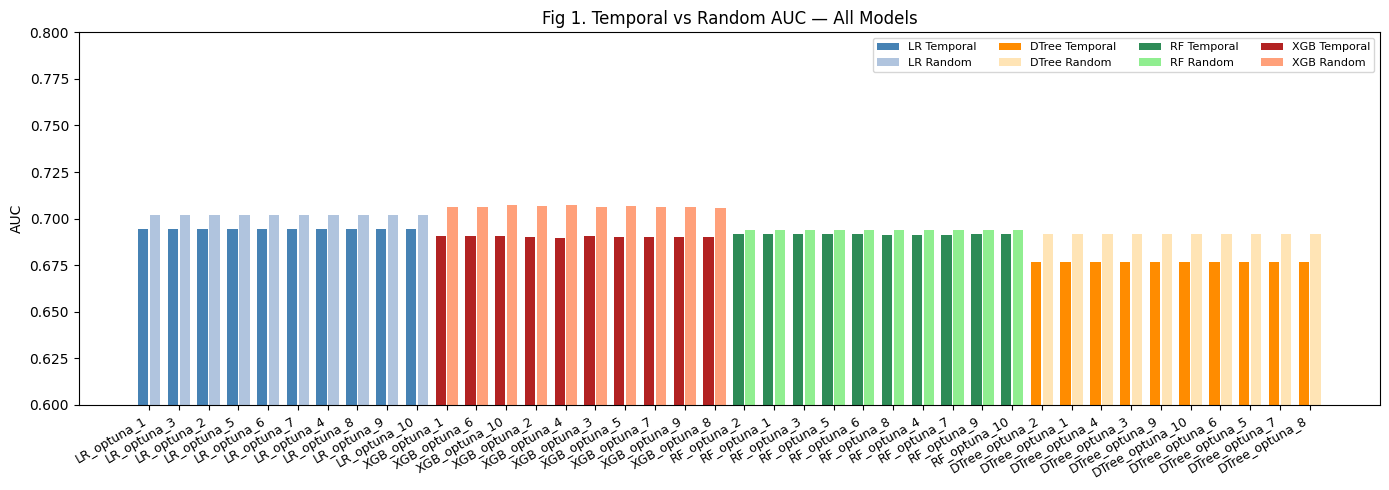

In [38]:
fig, ax = plt.subplots(figsize=(14, 5))

model_names = df_results['Model'].tolist()
t_aucs = df_results['Temporal AUC'].tolist()
r_aucs = df_results['Random AUC'].tolist()

family_colors = {
    'Logistic Regression': ('steelblue', 'lightsteelblue'),
    'Decision Tree': ('darkorange', 'moccasin'),
    'Random Forest': ('seagreen', 'lightgreen'),
    'XGBoost': ('firebrick', 'lightsalmon'),
}

x = np.arange(len(model_names))
for i, name in enumerate(model_names):
    family = infer_family(name)
    c1, c2 = family_colors.get(family, ('gray', 'lightgray'))
    ax.bar(x[i] - 0.2, t_aucs[i], width=0.35, color=c1)
    ax.bar(x[i] + 0.2, r_aucs[i], width=0.35, color=c2)

# 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue',  label='LR Temporal'),
    Patch(facecolor='lightsteelblue', label='LR Random'),
    Patch(facecolor='darkorange', label='DTree Temporal'),
    Patch(facecolor='moccasin',   label='DTree Random'),
    Patch(facecolor='seagreen',   label='RF Temporal'),
    Patch(facecolor='lightgreen', label='RF Random'),
    Patch(facecolor='firebrick',  label='XGB Temporal'),
    Patch(facecolor='lightsalmon',label='XGB Random'),
]
ax.legend(handles=legend_elements, fontsize=8, ncol=4)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.set_ylim(0.60, 0.80)
ax.set_ylabel('AUC')
ax.set_title('Fig 1. Temporal vs Random AUC — All Models')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig('/content/fig1_auc_comparison.png', dpi=150)
plt.show()

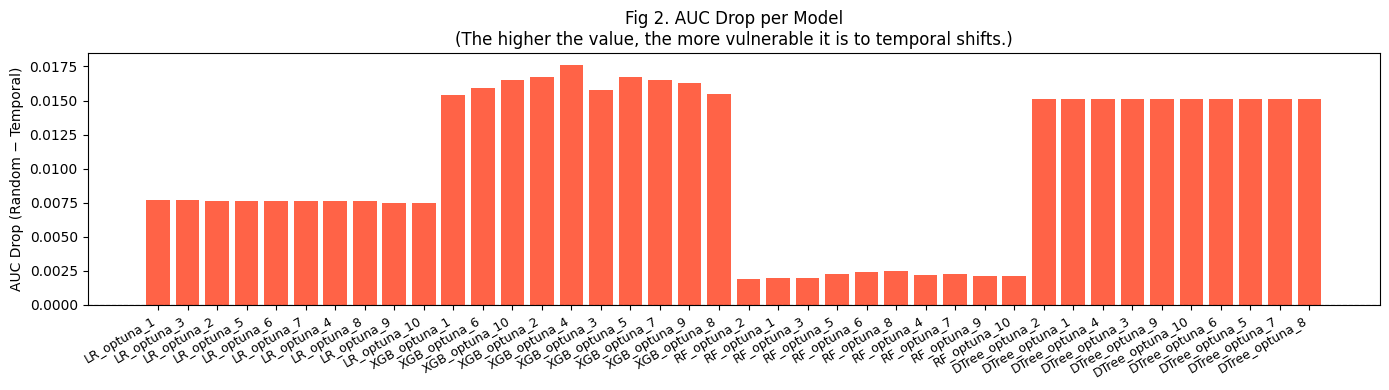

In [39]:
# ═══════════════════════════════════════════════════════════════════════
# Figure 2: AUC Drop (Temporal how much decrease)
# ═══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 4))

drops = df_results['AUC Drop'].tolist()
colors = ['tomato' if d > 0 else 'seagreen' for d in drops]

ax.bar(model_names, drops, color=colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(np.arange(len(model_names)))
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('AUC Drop (Random − Temporal)')
ax.set_title('Fig 2. AUC Drop per Model\n(The higher the value, the more vulnerable it is to temporal shifts.)')
plt.tight_layout()
plt.savefig('/content/fig2_auc_drop.png', dpi=150)
plt.show()

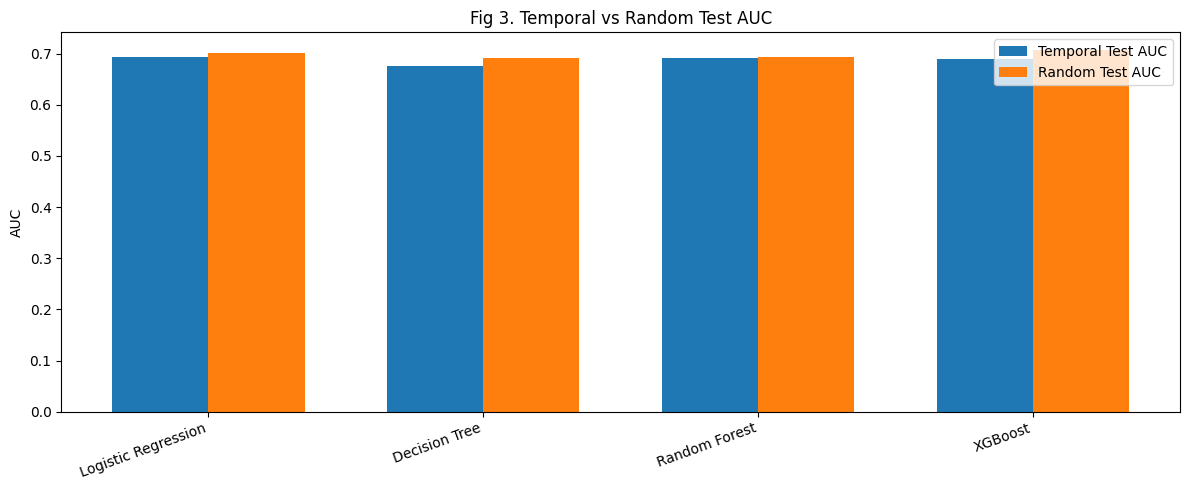

In [40]:
# ── Fig 3 ──────────────────────────────────────────────────────────────
family_order = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
family_display = {
    'Logistic Regression': 'Logistic Regression',
    'Decision Tree': 'Decision Tree',
    'Random Forest': 'Random Forest',
    'XGBoost': 'XGBoost',
}
family_colors = {
    'Logistic Regression': '#1f77b4',
    'Decision Tree': '#ff7f0e',
    'Random Forest': '#2ca02c',
    'XGBoost': '#d62728',
}

plot_df = df_representatives.copy()
plot_df['Family'] = plot_df['Model'].apply(infer_family)
plot_df['Family'] = pd.Categorical(plot_df['Family'], categories=family_order, ordered=True)
plot_df = plot_df.sort_values('Family').copy()
plot_df['Display'] = plot_df['Family'].map(family_display)

FAIR_MODELS_PLOT = plot_df['Model'].tolist()
FAIR_FAMILIES_PLOT = plot_df['Family'].astype(str).tolist()
FAIR_LABELS_PLOT = plot_df['Display'].tolist()
colors_fair = [family_colors.get(f, '#9467bd') for f in FAIR_FAMILIES_PLOT]

x = np.arange(len(plot_df))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, plot_df['Temporal AUC'], width=width, label='Temporal Test AUC', color='#1f77b4')
ax.bar(x + width/2, plot_df['Random AUC'], width=width, label='Random Test AUC', color='#ff7f0e')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Display'], rotation=20, ha='right')
ax.set_ylabel('AUC')
ax.set_title('Fig 3. Temporal vs Random Test AUC')
ax.legend()
plt.tight_layout()
plt.savefig('/content/fig3_auc_comparison.png', dpi=150)
plt.show()

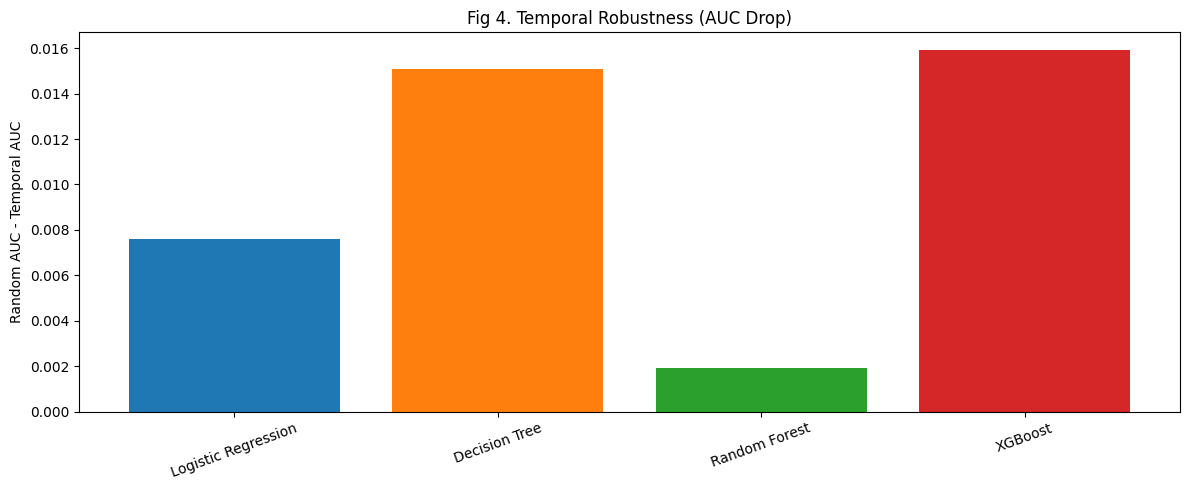

In [41]:
# ── Fig 4 ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(plot_df['Display'], plot_df['AUC Drop'], color=[family_colors.get(f, '#2ca02c') for f in plot_df['Family'].astype(str)])
ax.set_ylabel('Random AUC - Temporal AUC')
ax.set_title('Fig 4. Temporal Robustness (AUC Drop)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('/content/fig4_auc_drop.png', dpi=150)
plt.show()

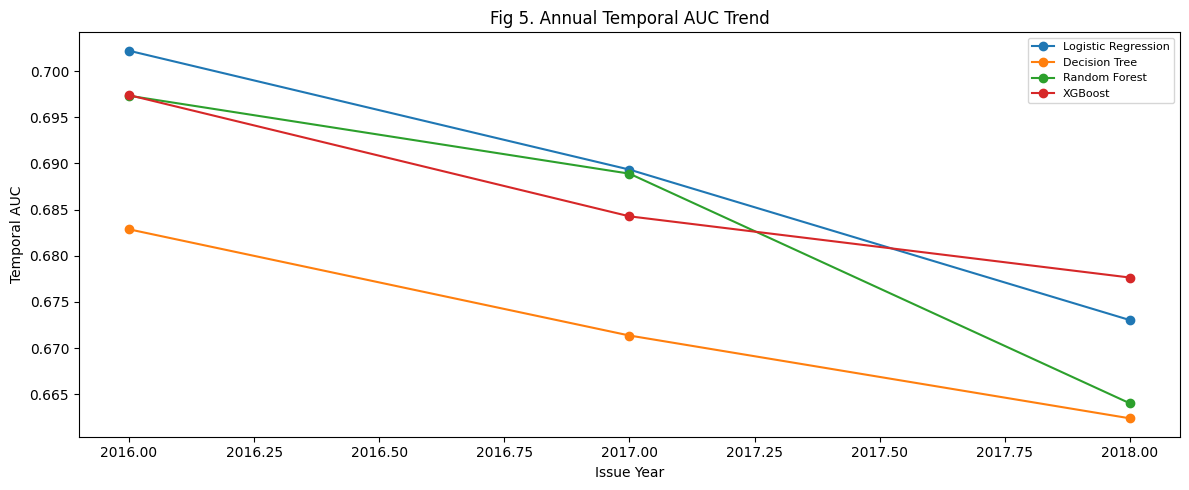

In [42]:
# ── Fig 5 ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for mname, family_label in zip(FAIR_MODELS_PLOT, FAIR_LABELS_PLOT):
    year_map = all_results[mname]['yearly']
    years = sorted(year_map.keys())
    vals = [year_map[y] for y in years]
    ax.plot(years, vals, marker='o', label=family_label)
ax.set_xlabel('Issue Year')
ax.set_ylabel('Temporal AUC')
ax.set_title('Fig 5. Annual Temporal AUC Trend')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/content/fig5_auc_over_time.png', dpi=150)
plt.show()

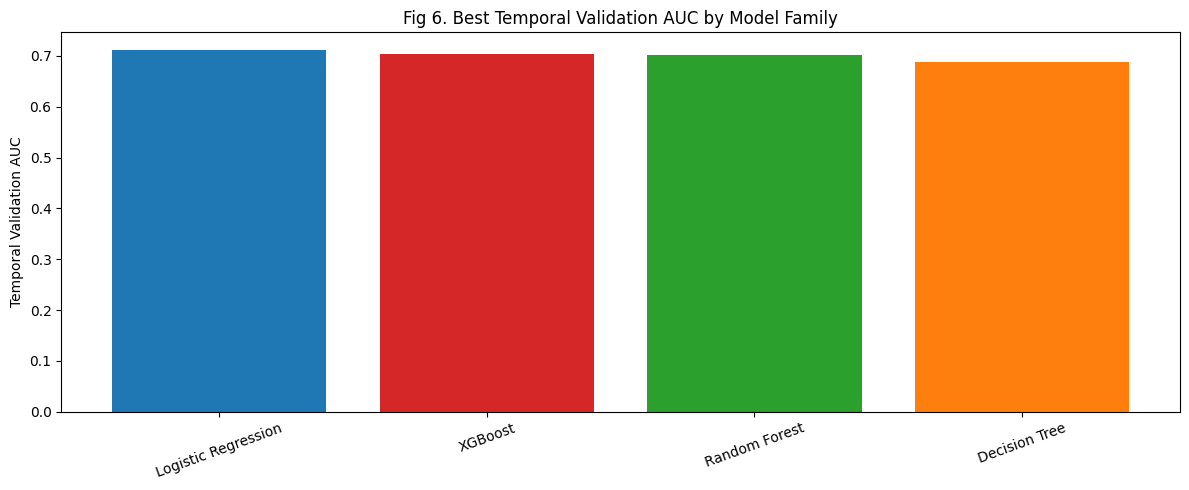

In [43]:
# ── Fig 5 ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig4_df = df_representatives.sort_values('Temporal Val AUC', ascending=False).copy()
fig4_df['Family'] = fig4_df['Model'].apply(infer_family)
fig4_df['Display'] = fig4_df['Family'].map(family_display)
ax.bar(fig4_df['Display'], fig4_df['Temporal Val AUC'], color=[family_colors.get(f, '#9467bd') for f in fig4_df['Family']])
ax.set_ylabel('Temporal Validation AUC')
ax.set_title('Fig 6. Best Temporal Validation AUC by Model Family')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('/content/fig6_validation_auc.png', dpi=150)
plt.show()

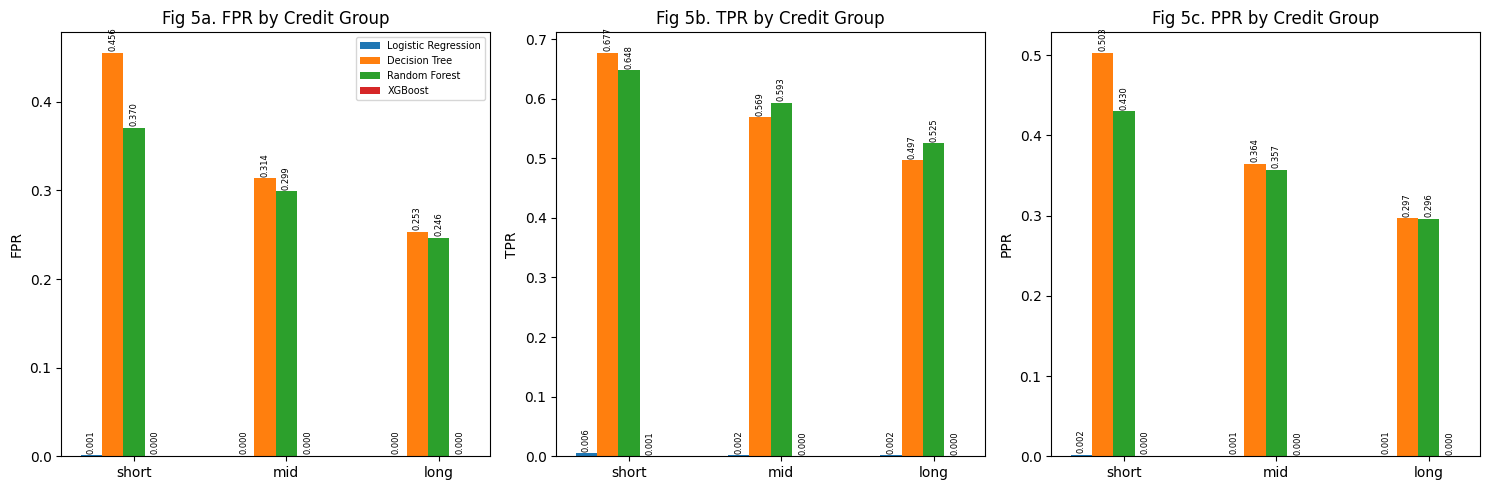

In [44]:
# ── Fig 7 ──────────────────────────────────────────────────────────────
FAIR_MODELS_PLOT = REPRESENTATIVE_MODELS.copy()
family_map = dict(zip(representative_lookup['Model'], representative_lookup['Family']))
FAIR_LABELS_PLOT = [family_display.get(family_map.get(m, ''), m) for m in FAIR_MODELS_PLOT]
colors_fair = [family_colors.get(family_map.get(m, ''), '#9467bd') for m in FAIR_MODELS_PLOT]

credit_groups = ['short', 'mid', 'long']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['FPR', 'TPR', 'PPR']
for ax_i, metric in enumerate(metrics):
    x = np.arange(len(credit_groups))
    width = 0.14
    for j, (mname, family_label, col) in enumerate(zip(FAIR_MODELS_PLOT, FAIR_LABELS_PLOT, colors_fair)):
        df_f = fairness_results.get(mname, {}).get('credit', pd.DataFrame(columns=['group'] + metrics))
        vals = df_f.set_index('group').reindex(credit_groups)[metric].fillna(0).tolist()
        offset = (j - len(FAIR_MODELS_PLOT) / 2) * width
        bars = axes[ax_i].bar(x + offset, vals, width=width, label=family_label, color=col)
        for bar, val in zip(bars, vals):
            axes[ax_i].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{val:.3f}',
                ha='center',
                va='bottom',
                fontsize=6,
                rotation=90
            )
    axes[ax_i].set_xticks(x)
    axes[ax_i].set_xticklabels(credit_groups)
    axes[ax_i].set_title(f'Fig 5{chr(97+ax_i)}. {metric} by Credit Group')
    axes[ax_i].set_ylabel(metric)
    if ax_i == 0:
        axes[ax_i].legend(fontsize=7)
plt.tight_layout()
plt.savefig('/content/fig7_fairness_credit.png', dpi=150)
plt.show()

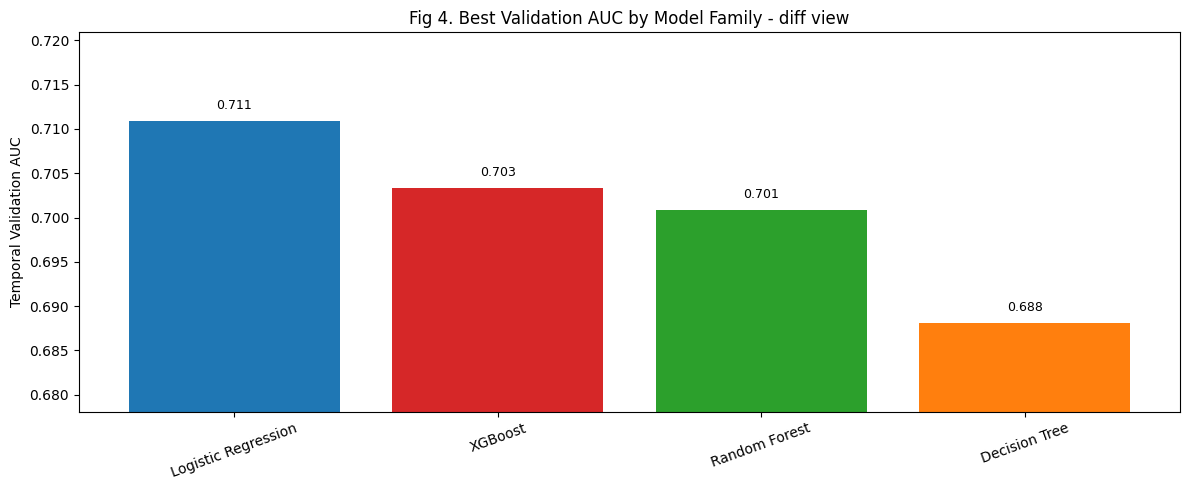

In [45]:
# Figure 4 alternate view: sorted high-to-low with a careful zoomed y-axis
fig4_alt_df = df_representatives.copy()
fig4_alt_df['Family'] = fig4_alt_df['Model'].apply(infer_family)
fig4_alt_df['Display'] = fig4_alt_df['Family'].map(family_display)
fig4_alt_df = fig4_alt_df.sort_values('Temporal Val AUC', ascending=False).copy()

ymin = max(0.0, fig4_alt_df['Temporal Val AUC'].min() - 0.01)
ymax = min(1.0, fig4_alt_df['Temporal Val AUC'].max() + 0.01)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    fig4_alt_df['Display'],
    fig4_alt_df['Temporal Val AUC'],
    color=[family_colors.get(f, '#9467bd') for f in fig4_alt_df['Family']]
)
ax.set_ylabel('Temporal Validation AUC')
ax.set_title('Fig 4. Best Validation AUC by Model Family - diff view')
ax.set_ylim(ymin, ymax)
ax.tick_params(axis='x', rotation=20)

for bar, val in zip(bars, fig4_alt_df['Temporal Val AUC']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


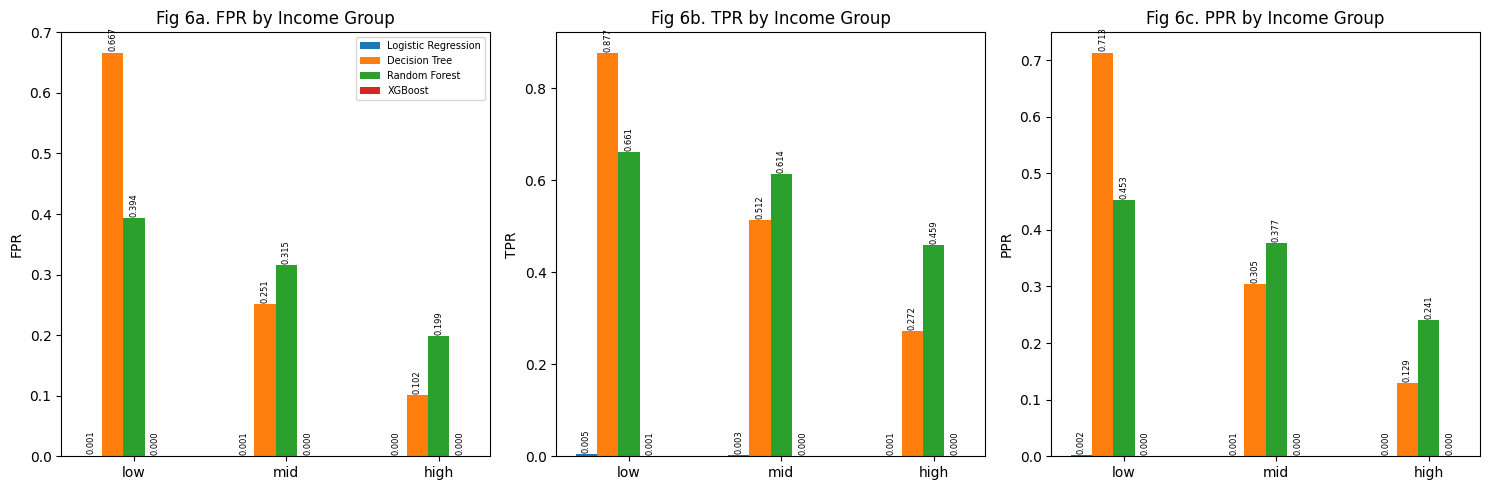

In [46]:
# Figure 6: Fairness by income group at threshold 0.5
FAIR_MODELS_PLOT = REPRESENTATIVE_MODELS.copy()
family_map = dict(zip(representative_lookup['Model'], representative_lookup['Family']))
FAIR_LABELS_PLOT = [family_display.get(family_map.get(m, ''), m) for m in FAIR_MODELS_PLOT]
colors_fair = [family_colors.get(family_map.get(m, ''), '#9467bd') for m in FAIR_MODELS_PLOT]

income_groups = ['low', 'mid', 'high']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax_i, metric in enumerate(metrics):
    x = np.arange(len(income_groups))
    width = 0.14
    for j, (mname, family_label, col) in enumerate(zip(FAIR_MODELS_PLOT, FAIR_LABELS_PLOT, colors_fair)):
        df_f = fairness_results.get(mname, {}).get('income', pd.DataFrame(columns=['group'] + metrics))
        vals = df_f.set_index('group').reindex(income_groups)[metric].fillna(0).tolist()
        offset = (j - len(FAIR_MODELS_PLOT) / 2) * width
        bars = axes[ax_i].bar(x + offset, vals, width=width, label=family_label, color=col)
        for bar, val in zip(bars, vals):
            axes[ax_i].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{val:.3f}',
                ha='center',
                va='bottom',
                fontsize=6,
                rotation=90
            )
    axes[ax_i].set_xticks(x)
    axes[ax_i].set_xticklabels(income_groups)
    axes[ax_i].set_title(f'Fig 6{chr(97+ax_i)}. {metric} by Income Group')
    axes[ax_i].set_ylabel(metric)
    if ax_i == 0:
        axes[ax_i].legend(fontsize=7)
plt.tight_layout()
plt.savefig('/content/fig6_fairness_income.png', dpi=150)
plt.show()


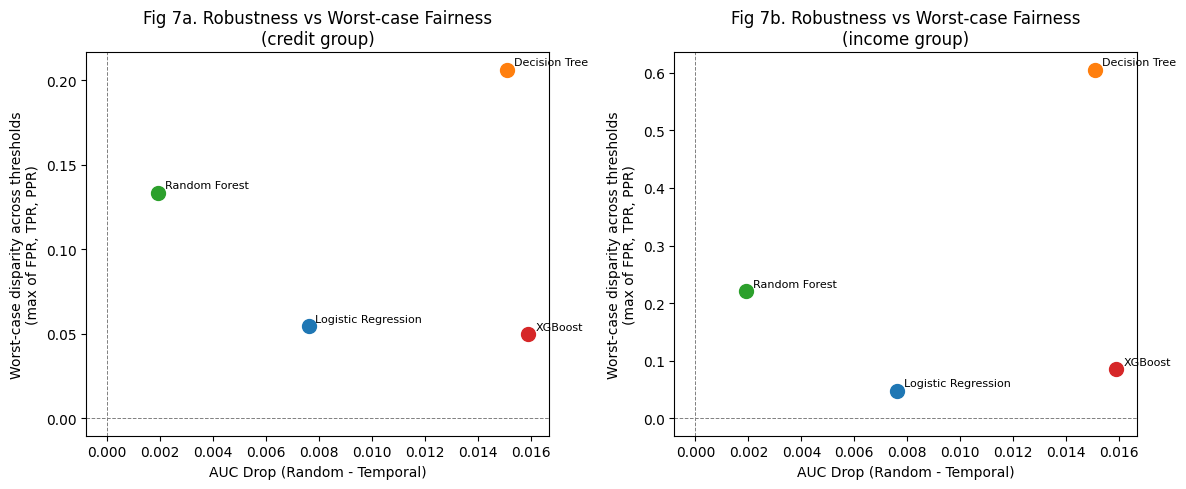

In [47]:
# Figure 7: Robustness vs worst-case fairness disparity
FAIR_MODELS_PLOT = REPRESENTATIVE_MODELS.copy()
family_map = dict(zip(representative_lookup['Model'], representative_lookup['Family']))
FAIR_LABELS_PLOT = [family_display.get(family_map.get(m, ''), m) for m in FAIR_MODELS_PLOT]
colors_fair = [family_colors.get(family_map.get(m, ''), '#9467bd') for m in FAIR_MODELS_PLOT]

tradeoff_df = df_fairness_summary[df_fairness_summary['Model'].isin(FAIR_MODELS_PLOT)].copy()
tradeoff_df['Worst Credit Overall_disp'] = tradeoff_df[['Worst Credit FPR_disp', 'Worst Credit TPR_disp', 'Worst Credit PPR_disp']].max(axis=1)
tradeoff_df['Worst Income Overall_disp'] = tradeoff_df[['Worst Income FPR_disp', 'Worst Income TPR_disp', 'Worst Income PPR_disp']].max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax_i, (y_col, title_suffix) in enumerate([
    ('Worst Credit Overall_disp', 'credit group'),
    ('Worst Income Overall_disp', 'income group'),
]):
    for mname, family_label, col in zip(FAIR_MODELS_PLOT, FAIR_LABELS_PLOT, colors_fair):
        row = tradeoff_df[tradeoff_df['Model'] == mname].iloc[0]
        x_val = row['AUC Drop']
        y_val = row[y_col]
        axes[ax_i].scatter(x_val, y_val, color=col, s=100, label=family_label, zorder=3)
        axes[ax_i].annotate(family_label, (x_val, y_val), textcoords='offset points', xytext=(5, 3), fontsize=8)
    axes[ax_i].set_xlabel('AUC Drop (Random - Temporal)')
    axes[ax_i].set_ylabel('Worst-case disparity across thresholds\n(max of FPR, TPR, PPR)')
    axes[ax_i].set_title(f'Fig 7{chr(97+ax_i)}. Robustness vs Worst-case Fairness\n({title_suffix})')
    axes[ax_i].axhline(0, color='gray', linestyle='--', linewidth=0.7)
    axes[ax_i].axvline(0, color='gray', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.savefig('/content/fig7_tradeoff.png', dpi=150)
plt.show()


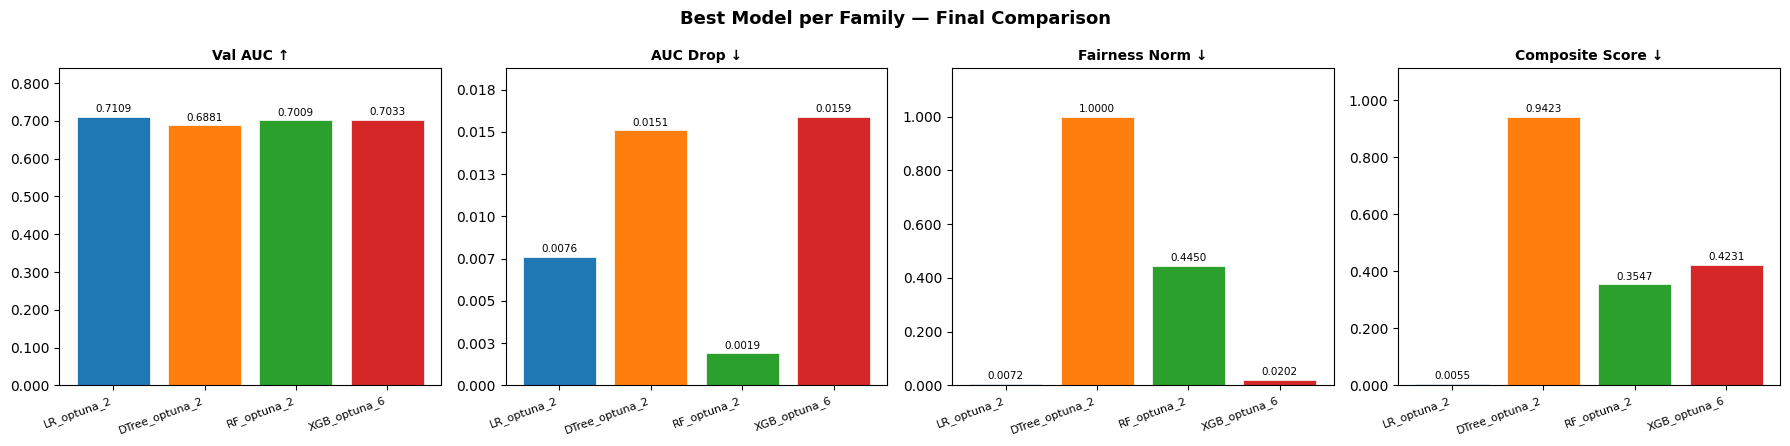

Saved: slide_fig1_best_model_per_family.png


In [48]:
# ════════════════════════════════════════════════════════════════════════════════
# SLIDE PLOT ① : Best Model per Family — Final Comparison
# 필요한 변수: df_representatives, df_ranked, REPRESENTATIVE_MODELS, representative_lookup
# ════════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

family_colors_bar = {
    'Logistic Regression': '#1f77b4',
    'Decision Tree':       '#ff7f0e',
    'Random Forest':       '#2ca02c',
    'XGBoost':             '#d62728',
}

# representative 모델들의 composite score, fairness norm 포함한 df 만들기
plot_df = df_ranked[df_ranked['Model'].isin(REPRESENTATIVE_MODELS)].copy()
plot_df['Family'] = plot_df['Model'].apply(infer_family)
plot_df['Model']  = pd.Categorical(plot_df['Model'], categories=REPRESENTATIVE_MODELS, ordered=True)
plot_df = plot_df.sort_values('Model')

bar_colors = [family_colors_bar.get(f, '#9467bd') for f in plot_df['Family']]
x_labels   = plot_df['Model'].astype(str).tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle('Best Model per Family — Final Comparison', fontsize=13, fontweight='bold')

metrics = [
    ('Temporal Val AUC', 'Val AUC ↑',       True,  '%.4f'),
    ('AUC Drop',         'AUC Drop ↓',       False, '%.4f'),
    ('_fair_norm',       'Fairness Norm ↓',  False, '%.4f'),
    ('composite_score',  'Composite Score ↓',False, '%.4f'),
]

for ax, (col, title, higher_better, fmt) in zip(axes, metrics):
    vals = plot_df[col].tolist()
    bars = ax.bar(x_labels, vals, color=bar_colors, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=20, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))
    ax.set_ylim(0, max(vals) * 1.18)

plt.tight_layout()
plt.savefig('/content/slide_fig1_best_model_per_family.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: slide_fig1_best_model_per_family.png')

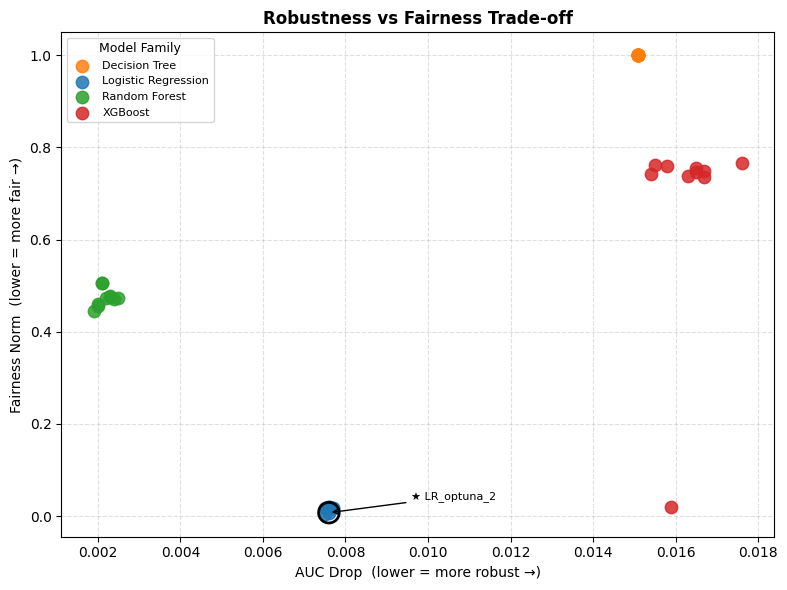

Saved: slide_fig2_tradeoff_scatter_v2.png


In [49]:
import matplotlib.pyplot as plt

family_colors_scatter = {
    'Random Forest': '#2ca02c',
    'Logistic Regression': '#1f77b4',
    'Decision Tree': '#ff7f0e',
    'XGBoost': '#d62728',
}

df_all = df_ranked.copy()
df_all['Family'] = df_all['Model'].apply(infer_family)

fig, ax = plt.subplots(figsize=(8, 6))

for family, grp in df_all.groupby('Family'):
    color = family_colors_scatter.get(family, '#9467bd')
    ax.scatter(grp['AUC Drop'], grp['_fair_norm'],
               color=color, s=80, alpha=0.85, label=family, zorder=3)

# ── Best Model 강조 (composite_score 기준 1등)
best_row = df_ranked.iloc[0]
ax.scatter(best_row['AUC Drop'], best_row['_fair_norm'],
           s=220, facecolors='none', edgecolors='black', linewidths=2, zorder=5)
ax.annotate(f'★ {best_row["Model"]}',
            xy=(best_row['AUC Drop'], best_row['_fair_norm']),
            xytext=(best_row['AUC Drop'] + 0.002, best_row['_fair_norm'] + 0.03),
            fontsize=8, color='black',
            arrowprops=dict(arrowstyle='->', color='black', lw=1))

ax.set_xlabel('AUC Drop  (lower = more robust →)', fontsize=10)
ax.set_ylabel('Fairness Norm  (lower = more fair →)', fontsize=10)
ax.set_title('Robustness vs Fairness Trade-off', fontsize=12, fontweight='bold')
ax.legend(title='Model Family', fontsize=8, title_fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('/content/slide_fig2_tradeoff_scatter_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: slide_fig2_tradeoff_scatter_v2.png')

Plot models: ['LR_optuna_2', 'DTree_optuna_2', 'RF_optuna_2', 'XGB_optuna_6']


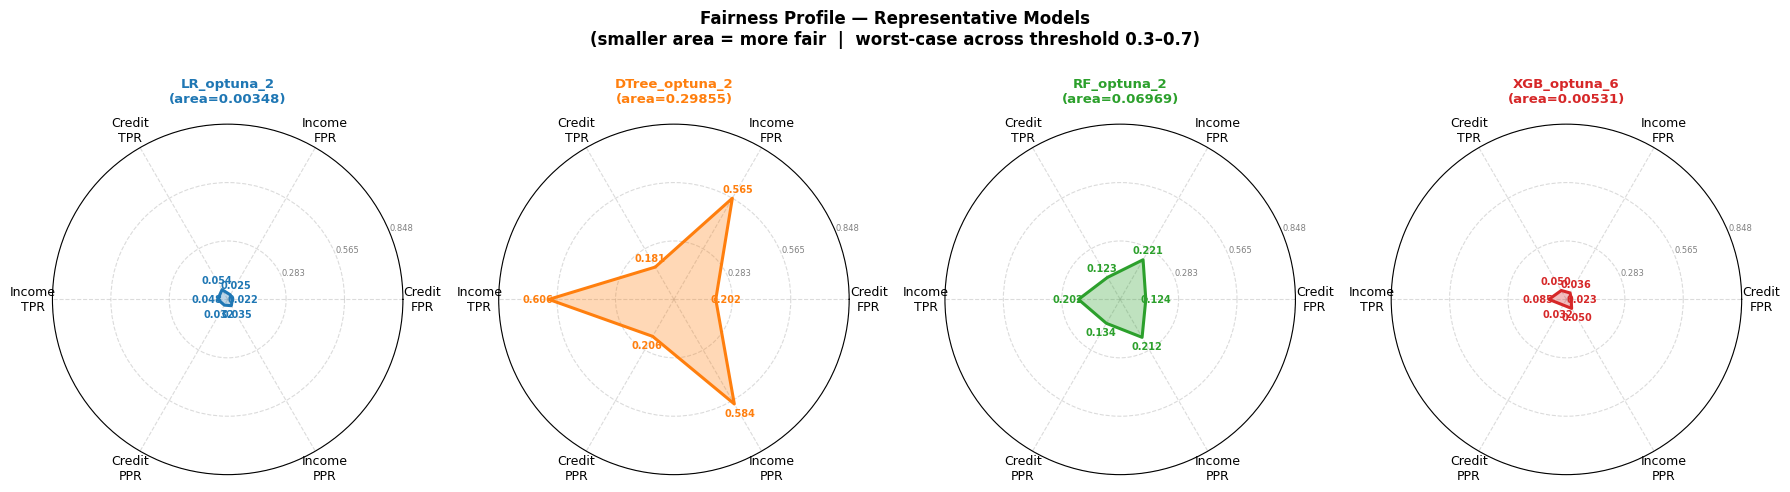

Saved: slide_fig3_fairness_radar_v8.png


In [50]:
import matplotlib.pyplot as plt
import numpy as np

family_colors_radar = {
    'Logistic Regression': '#1f77b4',
    'Decision Tree': '#ff7f0e',
    'Random Forest': '#2ca02c',
    'XGBoost': '#d62728',
}

labels = ['Credit\nFPR', 'Income\nFPR', 'Credit\nTPR',
          'Income\nTPR', 'Credit\nPPR', 'Income\nPPR']
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

disp_cols = [
    'Worst Credit FPR_disp', 'Worst Income FPR_disp',
    'Worst Credit TPR_disp', 'Worst Income TPR_disp',
    'Worst Credit PPR_disp', 'Worst Income PPR_disp',
]

ZERO_THRESHOLD = 1e-4

# 하드코딩 제거 → REPRESENTATIVE_MODELS 그대로 사용
PLOT_MODELS = REPRESENTATIVE_MODELS.copy()
print("Plot models:", PLOT_MODELS)

# 값 수집
model_vals = {}
for m in PLOT_MODELS:
    rows = df_ranked[df_ranked['Model'] == m]
    if rows.empty:
        continue
    row = rows.iloc[0]
    model_vals[m] = [row[col] for col in disp_cols]

PLOT_MODELS = [m for m in PLOT_MODELS if m in model_vals]

global_max = max([max(v) for v in model_vals.values()])
y_max_global = global_max * 1.4
yticks = np.linspace(0, y_max_global, 4)[1:]

def radar_area(values):
    r = np.array(values)
    return 0.5 * abs(sum(
        r[i] * r[(i+1) % N] * np.sin(angles[(i+1) % N] - angles[i])
        for i in range(N)
    ))

fig, axes = plt.subplots(1, len(PLOT_MODELS),
                         figsize=(4.5 * len(PLOT_MODELS), 5.0),
                         subplot_kw=dict(polar=True))
fig.suptitle('Fairness Profile — Representative Models\n(smaller area = more fair  |  worst-case across threshold 0.3–0.7)',
             fontsize=12, fontweight='bold', y=1.02)

for ax, model_name in zip(axes, PLOT_MODELS):
    family = infer_family(model_name)
    color = family_colors_radar.get(family, '#9467bd')
    values = model_vals[model_name]
    is_zero = max(values) < ZERO_THRESHOLD
    area = radar_area(values)
    closed = values + [values[0]]

    if is_zero:
        ax.scatter([0], [0], s=120, color=color, zorder=5)
        ax.text(0, y_max_global * 0.1, '≈ 0',
                ha='center', va='bottom', fontsize=11,
                color=color, fontweight='bold')
    else:
        ax.plot(angles, closed, color=color, linewidth=2.2, zorder=3)
        ax.fill(angles, closed, color=color, alpha=0.30, zorder=2)
        for ang, val in zip(angles[:-1], values):
            ax.text(ang, val + y_max_global * 0.06, f'{val:.3f}',
                    ha='center', va='center', fontsize=7,
                    color=color, fontweight='bold')

    ax.set_ylim(0, y_max_global)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{v:.3f}' for v in yticks], fontsize=6, color='gray')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.45)

    title_suffix = '(≈ perfectly fair)' if is_zero else f'(area={area:.5f})'
    ax.set_title(f'{model_name}\n{title_suffix}',
                 fontsize=9.5, fontweight='bold', color=color, pad=16)

plt.tight_layout()
plt.savefig('/content/slide_fig3_fairness_radar_v8.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: slide_fig3_fairness_radar_v8.png')

## 8. Output Final Summary Table (For Presentation)

In [51]:
# Representative summary table aligned with the current pipeline
df_summary = df_ranked[df_ranked['Model'].isin(REPRESENTATIVE_MODELS)].copy()
df_summary['Model'] = pd.Categorical(df_summary['Model'], categories=REPRESENTATIVE_MODELS, ordered=True)
df_summary = df_summary.sort_values('Model')
print('=== Summary Table (Representative Models) ===')
print(df_summary.to_string(index=False))

df_summary.to_csv('/content/prefinal_summary.csv', index=False)
df_results.to_csv('/content/prefinal_full_results.csv', index=False)
print('\nCSV saved: prefinal_summary.csv, prefinal_full_results.csv')

=== Summary Table (Representative Models) ===
         Model  Temporal Val AUC  Val AUC Drop  Val F1  Temporal AUC  Accuracy  AUC Drop     F1  Worst Credit FPR_disp  Worst Income FPR_disp  Worst Credit TPR_disp  Worst Income TPR_disp  Worst Credit PPR_disp  Worst Income PPR_disp  _fair_norm  composite_score
   LR_optuna_2            0.7109       -0.0108  0.4273        0.6945    0.6587    0.0076 0.4442                 0.0224                 0.0255                 0.0544                 0.0482                 0.0321                 0.0352    0.007247         0.005467
DTree_optuna_2            0.6881       -0.0008  0.4028        0.6769    0.6415    0.0151 0.4292                 0.2024                 0.5650                 0.1806                 0.6055                 0.2064                 0.5840    1.000000         0.942253
   RF_optuna_2            0.7009       -0.0100  0.4175        0.6920    0.6607    0.0019 0.4407                 0.1239                 0.2214                 0.1229 

## 9. Save Files (Google Drive)
Save Resulting PNG + CSV to Drive

In [52]:
# import shutil, os

# SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/CSCI567'
# os.makedirs(SAVE_DIR, exist_ok=True)

# files_to_save = [
#     '/content/fig1_auc_comparison.png',
#     '/content/fig2_auc_drop.png',
#     '/content/fig3_auc_over_time.png',
#     '/content/fig4_validation_auc.png',
#     '/content/fig5_fairness_credit.png',
#     '/content/fig6_fairness_income.png',
#     '/content/fig7_tradeoff.png',
#     '/content/prefinal_summary.csv',
#     '/content/prefinal_full_results.csv',
# ]

# for f in files_to_save:
#     if os.path.exists(f):
#         shutil.copy(f, SAVE_DIR)
#         print(f'Saved: {os.path.basename(f)}')
#     else:
#         print(f'NOT FOUND: {f}')